<div style="text-align:center; line-height:1.6">

МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИЙСКОЙ ФЕДЕРАЦИИ<br>
Новосибирский государственный технический университет<br>
Факультет автоматики и вычислительной техники

<br><br>

# ОТЧЁТ
## по лабораторной работе № 1
### «Линейная регрессия и факторный анализ»

Датасет: **California Housing Prices** (Kaggle)

<br><br>

</div>

<div style="text-align:right">
Выполнил: студент гр. АВТ-313<br>
Савченко В.<br>
Проверил: ____________________
</div>

<div style="text-align:center">Новосибирск, 2026</div>

---

## Содержание

1. [Введение](#1)
2. [Описание датасета](#2)
3. [Подготовка данных](#3)
4. [Ход работы](#4)
   - [4.1. Корреляционный анализ](#41)
   - [4.2. Оценка мультиколлинеарности: коэффициент VIF](#42)
   - [4.3. Регрессионные модели на исходных признаках](#43)
   - [4.4. Диагностика остатков](#44)
   - [4.5. Устранение мультиколлинеарности: метод главных компонент](#45)
   - [4.6. Регрессия на главных компонентах и сравнение моделей](#46)
5. [Заключение](#5)
6. [Список источников](#6)
7. [Приложение. Листинг программного кода](#7)

<a id="1"></a>
# 1. Введение

**Цель работы** — изучение основ линейной регрессии, построение простейших регрессионных моделей,
обучение модели на реальных данных и оценка её качества.

**Задачи работы:**

1. Загрузить реальный набор данных с платформы Kaggle.
2. Провести первичный анализ: описательные статистики (включая меры формы распределения —
   асимметрию и эксцесс) и визуализацию распределений признаков и целевой переменной.
3. Выполнить предобработку: удаление пропусков, кодирование категориальных переменных, масштабирование.
4. Построить матрицу корреляций и оценить мультиколлинеарность по коэффициенту VIF.
5. Построить три регрессионные модели — линейную (МНК), гребневую (Ridge) и лассо (Lasso), —
   оценить качество по метрикам RMSE, MAE, R², скорректированному R² и MAPE с использованием
   кросс-валидации.
6. Устранить мультиколлинеарность и снизить размерность методом главных компонент (PCA).
7. Повторно обучить модели на главных компонентах и сравнить метрики качества.

**Критерии оценки метрик**, используемые далее при интерпретации результатов:

| Метрика | Смысл | Как читать значение |
|---|---|---|
| RMSE | корень из среднего квадрата ошибки, в долларах | сравнивается со стандартным отклонением цены σ(y): RMSE < σ(y) означает, что модель полезнее прогноза «средним» |
| MAE | средняя абсолютная ошибка, в долларах | устойчива к выбросам; разрыв между RMSE и MAE указывает на наличие крупных промахов |
| R² | доля объяснённой дисперсии | 0 — не лучше среднего, 1 — идеально; для социально-экономических данных 0,5–0,7 считается умеренным результатом |
| R² adj | R² со штрафом за число признаков | если заметно ниже R², в модели есть лишние предикторы |
| MAPE | средняя относительная ошибка, % | шкала Льюиса: < 10 % — высокая точность, 10–20 % — хорошая, 20–50 % — удовлетворительная, > 50 % — неудовлетворительная |

Работа выполнена на языке Python 3 с использованием библиотек `pandas`, `NumPy`, `SciPy`,
`Matplotlib`, `Seaborn`, `scikit-learn` и `statsmodels`.

In [1]:
# Импорт библиотек
import os                      # работа с путями и проверка наличия файла
import urllib.request          # автоматическое скачивание датасета
import warnings                # подавление технических предупреждений sklearn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats        # асимметрия, эксцесс, тест Жарка — Бера, Q-Q график

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             mean_absolute_percentage_error)
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42              # фиксируем зерно ГСЧ ради воспроизводимости результатов
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"
pd.set_option("display.width", 130)
print("Библиотеки загружены")

Библиотеки загружены


<a id="2"></a>
# 2. Описание датасета

В работе используется набор данных **California Housing Prices** (Kaggle, автор Cam Nugent),
построенный по материалам переписи населения США 1990 года. Каждая строка описывает один жилой
квартал (*block group*) штата Калифорния. Исходный объём выборки — **20 640 наблюдений** и
**10 переменных** (9 признаков и целевая переменная).

Целевая переменная — `median_house_value`, медианная стоимость дома в квартале (в долларах США).
Задача является **задачей регрессии**, так как целевая переменная непрерывна.

**Таблица 1 — Состав переменных датасета**

| Переменная | Тип | Смысл |
|---|---|---|
| `longitude` | веществ. | географическая долгота квартала |
| `latitude` | веществ. | географическая широта квартала |
| `housing_median_age` | веществ. | медианный возраст зданий, лет |
| `total_rooms` | веществ. | общее число комнат в квартале |
| `total_bedrooms` | веществ. | общее число спален в квартале |
| `population` | веществ. | численность населения квартала |
| `households` | веществ. | число домохозяйств |
| `median_income` | веществ. | медианный доход домохозяйства (десятки тыс. $) |
| `ocean_proximity` | категор. | удалённость от океана (5 категорий) |
| `median_house_value` | веществ. | **целевая переменная** — медианная цена дома, $ |

In [2]:
# Загрузка данных (файл скачивается автоматически, если его нет рядом с ноутбуком)
CSV = "housing.csv"
URL = ("https://raw.githubusercontent.com/ageron/handson-ml2/"
       "master/datasets/housing/housing.csv")
if not os.path.exists(CSV):
    print("Файл не найден, скачиваем датасет...")
    urllib.request.urlretrieve(URL, CSV)

df = pd.read_csv(CSV)
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()     # типы столбцов и число непустых значений — сразу видно, где есть пропуски

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


### 2.1. Описательные статистики

К стандартному `describe()` добавлены **меры формы распределения**, без которых нельзя судить
о пригодности признака для линейной модели:

- **асимметрия (skew)** — мера скошенности. 0 — распределение симметрично; |skew| < 0,5 —
  практически симметрично; 0,5–1 — умеренная асимметрия; > 1 — сильная правосторонняя
  (длинный хвост больших значений);
- **эксцесс (kurtosis, избыточный)** — мера «тяжести хвостов». 0 — как у нормального
  распределения; > 3 — тяжёлые хвосты, то есть заметная доля экстремальных выбросов;
  < 0 — распределение более плоское, чем нормальное;
- **CV (коэффициент вариации)** = std / mean — относительный разброс; CV > 0,5 означает
  сильную неоднородность выборки.

In [4]:
# Описательные статистики + меры формы распределения
desc = df.describe().T
desc["skew"] = df.select_dtypes(include=np.number).skew()          # асимметрия
desc["kurtosis"] = df.select_dtypes(include=np.number).kurtosis()  # избыточный эксцесс
desc["CV"] = desc["std"] / desc["mean"]                            # коэффициент вариации
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,CV
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31,-0.30,-1.33,-0.02
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95,0.47,-1.12,0.06
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00,0.06,-0.80,0.44
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00,4.15,32.63,0.83
total_bedrooms,20433.0,537.87,421.39,1.00,296.00,435.00,647.00,6445.00,3.46,21.99,0.78
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00,4.94,73.55,0.79
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00,3.41,22.06,0.77
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00,1.65,4.95,0.49
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00,0.98,0.33,0.56


**Интерпретация таблицы (по каждому признаку):**

| Признак | skew | kurt | Что это значит |
|---|---|---|---|
| `longitude` | −0,30 | −1,33 | почти симметрично, распределение **двухвершинное** и плоское (эксцесс < 0) — два скопления кварталов: район Сан-Франциско и Лос-Анджелес |
| `latitude` | 0,47 | −1,12 | то же самое по широте: два географических кластера, а не один центр |
| `housing_median_age` | 0,06 | −0,80 | распределение симметричное и равномерное; **единственный признак, близкий к «хорошей» форме**, но с заметным столбцом на значении 52 (обрезка сверху) |
| `total_rooms` | 4,15 | 32,63 | сильнейшая правосторонняя асимметрия и очень тяжёлые хвосты: есть кварталы с 39 тыс. комнат при медиане 2127 |
| `total_bedrooms` | 3,46 | 21,99 | то же самое — признак-агрегат, зависящий от размера квартала |
| `population` | 4,94 | **73,55** | самый «выбросоопасный» признак: эксцесс 73,6 означает единичные кварталы с населением в десятки раз выше типичного (максимум 35 682 при медиане 1166) |
| `households` | 3,41 | 22,06 | аналогично |
| `median_income` | 1,65 | 4,95 | умеренно-сильная асимметрия, типичная для доходов (распределение Парето) |
| `median_house_value` | 0,98 | 0,33 | целевая переменная умеренно скошена вправо; хвосты близки к нормальным, но есть искусственный пик на 500 001 \$ |

**Вывод:** четыре признака-агрегата (`total_rooms`, `total_bedrooms`, `population`, `households`)
имеют экстремальную асимметрию и эксцесс, поскольку измеряют **размер квартала**, а не свойства
жилья. Это одновременно объясняет, почему они будут сильно коррелированы между собой (см. п. 4.1)
и почему в разделе 3 из них строятся относительные производные признаки.
Формальная проверка нормальности приведена ниже.

In [5]:
# Тест Жарка — Бера: H0 — распределение нормально. p-value < 0.05 => нормальность отвергается
jb = {c: dict(zip(["JB", "p-value"], stats.jarque_bera(df[c].dropna())[:2]))
      for c in df.select_dtypes(include=np.number).columns}
pd.DataFrame(jb).T.round(3)

,JB,p-value
longitude,1826.564,0.0
latitude,1821.268,0.0
housing_median_age,563.918,0.0
total_rooms,974409.652,0.0
total_bedrooms,452065.568,0.0
population,4734157.364,0.0
households,458228.560,0.0
median_income,30407.082,0.0
median_house_value,3380.475,0.0


У всех признаков p-value = 0,000, то есть **гипотеза нормальности отвергается для каждого**.
Для линейной регрессии это не запрет: МНК не требует нормальности *признаков*, требование
касается только *остатков* модели (проверяется в п. 4.4). Однако при n ≈ 20 000 тест Жарка — Бера
крайне чувствителен и отвергает нормальность даже при малых отклонениях, поэтому опираться
следует прежде всего на величины skew и kurt из таблицы выше.

### 2.2. Пропуски, дубликаты, категории

In [6]:
na = df.isna().sum()
print("Пропуски по признакам:")
print(na[na > 0])
print("\nПолных дубликатов строк:", df.duplicated().sum())
print("\nРаспределение категориального признака ocean_proximity:")
print(df["ocean_proximity"].value_counts())

Пропуски по признакам:
total_bedrooms    207
dtype: int64

Полных дубликатов строк: 0

Распределение категориального признака ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


**Что видно:** пропуски есть только в `total_bedrooms` — 207 значений, это **1,0 %** выборки.
Дубликатов нет. Категория `ISLAND` встречается всего 5 раз — это статистически незначимая группа,
и её коэффициент в модели заведомо будет ненадёжен (учитываем это при интерпретации).

### 2.3. Распределение признаков (Рисунок 1)

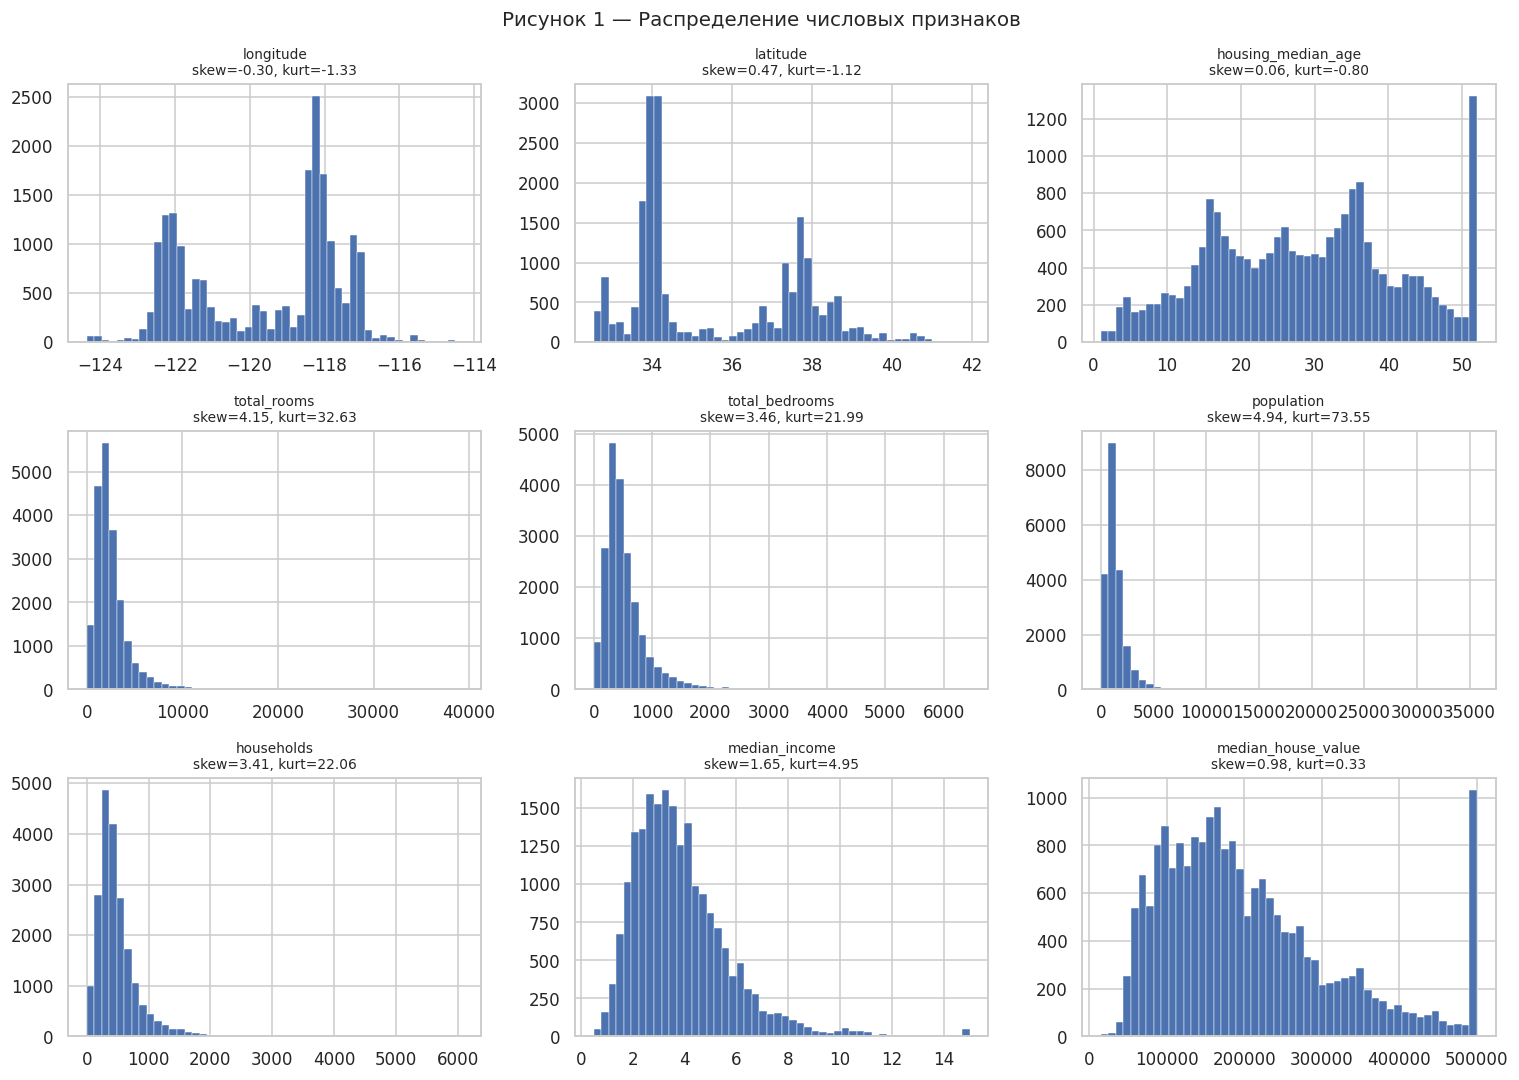

In [7]:
# Гистограммы всех числовых признаков; в заголовке — асимметрия и эксцесс
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, c in zip(axes.ravel(), num_cols):
    ax.hist(df[c].dropna(), bins=50, color="#4C72B0", edgecolor="white", linewidth=0.3)
    ax.set_title(f"{c}\nskew={df[c].skew():.2f}, kurt={df[c].kurtosis():.2f}", fontsize=9)
fig.suptitle("Рисунок 1 — Распределение числовых признаков", fontsize=13)
fig.tight_layout()
plt.show()

**Комментарий к рисунку 1.** Графики разделяются на три группы:

1. **Двухвершинные** (`longitude`, `latitude`) — два пика соответствуют двум агломерациям штата.
   Линейная модель по координатам сможет уловить только общий тренд «север — юг», но не такую
   структуру, поэтому в разделе 4.3 коэффициенты при координатах получатся крупными,
   а качество всё равно ограниченным.
2. **Резко скошенные вправо** (`total_rooms`, `total_bedrooms`, `population`, `households`,
   `median_income`) — основная масса значений слева, длинный хвост справа. Для МНК это означает,
   что небольшое число кварталов-гигантов будет иметь непропорционально большое влияние
   на оценки коэффициентов (высокое плечо).
3. **Обрезанные сверху** (`housing_median_age` — столбец на 52 годах, `median_house_value` —
   столбец на 500 001 \$). Это следствие методики сбора данных переписи.

**Вывод:** форма распределений подтверждает необходимость (а) удаления цензурированных значений
целевой переменной, (б) перехода к относительным признакам, (в) обязательной стандартизации.

### 2.4. Целевая переменная (Рисунок 2)

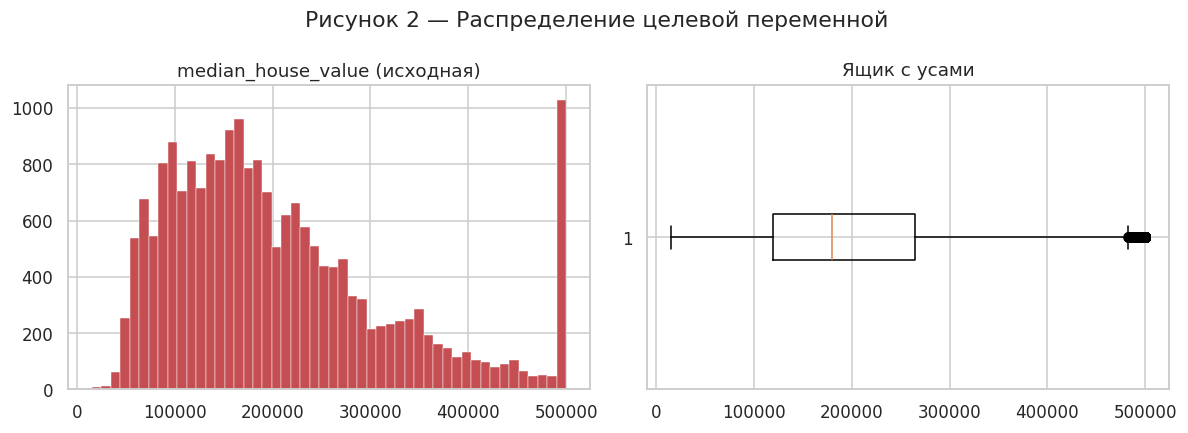

Наблюдений с обрезанным значением цены 500001 $: 965 (4.7 % выборки)
Медиана: 179700 $, среднее: 206856 $


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["median_house_value"], bins=50, color="#C44E52", edgecolor="white", linewidth=0.3)
axes[0].set_title("median_house_value (исходная)")
axes[1].boxplot(df["median_house_value"], vert=False)   # ящик с усами: медиана, квартили, выбросы
axes[1].set_title("Ящик с усами")
fig.suptitle("Рисунок 2 — Распределение целевой переменной")
fig.tight_layout()
plt.show()

cap = df["median_house_value"].max()
n_cap = int((df["median_house_value"] >= cap).sum())
print(f"Наблюдений с обрезанным значением цены {cap:.0f} $: {n_cap} "
      f"({n_cap / len(df) * 100:.1f} % выборки)")
print(f"Медиана: {df.median_house_value.median():.0f} $, среднее: {df.median_house_value.mean():.0f} $")

**Комментарий к рисунку 2.** Гистограмма скошена вправо (skew = 0,98): среднее (206 856 \$)
заметно выше медианы (179 700 \$) — классический признак правостороннего хвоста дорогого жилья.
На правом краю виден **аномальный столбец высотой ~1000 наблюдений** на значении 500 001 \$:
это не реальные цены, а *цензурирование* — все дома дороже полумиллиона записаны одним числом.
Ящик с усами показывает, что верхний ус доходит примерно до 480 тыс. \$, а за ним плотная
«стена» точек-выбросов — та же самая обрезка.

**Почему это важно:** цензурированные наблюдения систематически «тянут» линию регрессии вниз
в области дорогого жилья и искажают оценки коэффициентов. Поэтому 965 таких строк (4,7 % выборки)
удаляются в разделе 3.

### 2.5. Цена в разрезе категорий (Рисунок 3)

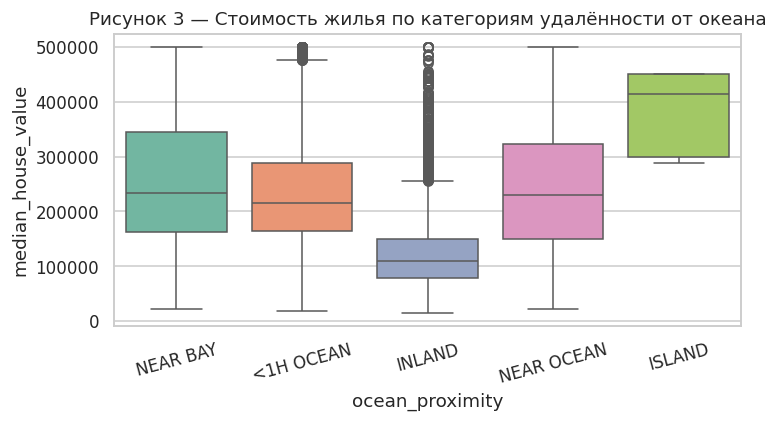

,count,median,mean
ocean_proximity,,,
<1H OCEAN,9136,214850.0,240084.0
INLAND,6551,108500.0,124805.0
ISLAND,5,414700.0,380440.0
NEAR BAY,2290,233800.0,259212.0
NEAR OCEAN,2658,229450.0,249434.0


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", ax=ax, palette="Set2")
ax.set_title("Рисунок 3 — Стоимость жилья по категориям удалённости от океана")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()

df.groupby("ocean_proximity")["median_house_value"].agg(["count", "median", "mean"]).round(0)

**Комментарий к рисунку 3.** Медианная цена по группам различается кратно:
`INLAND` — 108 500 \$ против `<1H OCEAN` — 214 850 \$, `NEAR BAY` — 233 800 \$ и
`NEAR OCEAN` — 229 450 \$. То есть жильё во внутренних районах штата стоит **вдвое дешевле**
прибрежного. Группы `<1H OCEAN`, `NEAR BAY` и `NEAR OCEAN` между собой почти не различаются —
фактически признак работает как бинарный «внутри штата / у побережья». Категория `ISLAND`
(медиана 414 700 \$) состоит всего из 5 наблюдений, поэтому её высокое положение
статистически недостоверно.

**Вывод:** категориальный признак несёт сильный полезный сигнал и обязателен к включению
в модель. Это подтвердится в п. 4.1: дамми-переменная `op_INLAND` окажется вторым по силе
предиктором после дохода.

<a id="3"></a>
# 3. Подготовка данных

Предобработка выполняется в следующем порядке.

1. **Удаление пропусков.** Пропуски есть только в `total_bedrooms` (207 значений, 1 % выборки),
   строки удаляются методом `dropna()`. Заполнение медианой здесь не даёт преимуществ: доля
   пропусков пренебрежимо мала, а удаление не смещает выборку.
2. **Удаление цензурированных значений** целевой переменной (965 наблюдений со значением
   500 001 \$) — см. комментарий к рисунку 2.
3. **Формирование производных признаков.** Абсолютные счётчики по кварталу малоинформативны
   сами по себе (они измеряют размер квартала, а не качество жилья), поэтому рассчитываются
   относительные показатели: `rooms_per_household`, `bedrooms_per_room`, `population_per_household`.
4. **Кодирование категориальной переменной.** `ocean_proximity` кодируется методом one-hot
   с удалением первой категории (`drop_first=True`) — иначе сумма всех дамми-столбцов тождественно
   равна единице и возникает полная линейная зависимость со свободным членом
   («ловушка фиктивных переменных»). Базовая категория — `<1H OCEAN`.
5. **Разделение выборки** на обучающую и тестовую в соотношении **80/20**
   (`train_test_split`, `random_state=42`).
6. **Нормализация (стандартизация).** Признаки различаются по масштабу на три порядка
   (доход — единицы, число комнат — тысячи), поэтому применяется `StandardScaler`
   (z-преобразование: вычитание среднего и деление на стандартное отклонение). Параметры
   рассчитываются **только на обучающей выборке** и затем применяются к тестовой — иначе
   информация о тесте «утекает» в модель и оценка качества оказывается завышенной.
   Стандартизация обязательна для Ridge и Lasso (иначе штраф распределяется между признаками
   непропорционально их масштабу) и для PCA (метод основан на дисперсиях).

In [10]:
# 3.1 Удаление пропусков и 3.2 цензурированных наблюдений
df = df.dropna().reset_index(drop=True)
df = df[df["median_house_value"] < cap].reset_index(drop=True)

# 3.3 Производные признаки: нормируем абсолютные счётчики на размер квартала
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

# 3.4 One-hot кодирование категориального признака (drop_first убирает базовую категорию)
df = pd.get_dummies(df, columns=["ocean_proximity"], prefix="op", drop_first=True, dtype=float)

TARGET = "median_house_value"
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Размер после предобработки:", df.shape)
print("Число признаков:", X.shape[1])
print("Признаки:", list(X.columns))
print(f"\nЦелевая переменная: среднее = {y.mean():.0f} $, "
      f"стандартное отклонение = {y.std():.0f} $")

Размер после предобработки: (19475, 16)
Число признаков: 15
Признаки: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'op_INLAND', 'op_ISLAND', 'op_NEAR BAY', 'op_NEAR OCEAN']

Целевая переменная: среднее = 192445 $, стандартное отклонение = 97703 $


In [11]:
# 3.5 Разделение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка: ", X_test.shape)

# 3.6 Стандартизация: scaler обучается ТОЛЬКО на train, чтобы не было утечки данных
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("\nПроверка: среднее train после стандартизации =", np.round(X_train_s.mean(), 6),
      ", ст. отклонение =", np.round(X_train_s.std(), 6))

Обучающая выборка: (15580, 15)
Тестовая выборка:  (3895, 15)

Проверка: среднее train после стандартизации = -0.0 , ст. отклонение = 1.0


Среднее равно 0, стандартное отклонение равно 1 — стандартизация выполнена корректно.
Стандартное отклонение цены **σ(y) = 97 703 \$** — это ориентир для оценки RMSE: модель имеет
смысл только если её RMSE заметно меньше этой величины (прогноз «всегда среднее» дал бы
RMSE ≈ σ(y) и R² = 0).

<a id="4"></a>
# 4. Ход работы

<a id="41"></a>
## 4.1. Корреляционный анализ

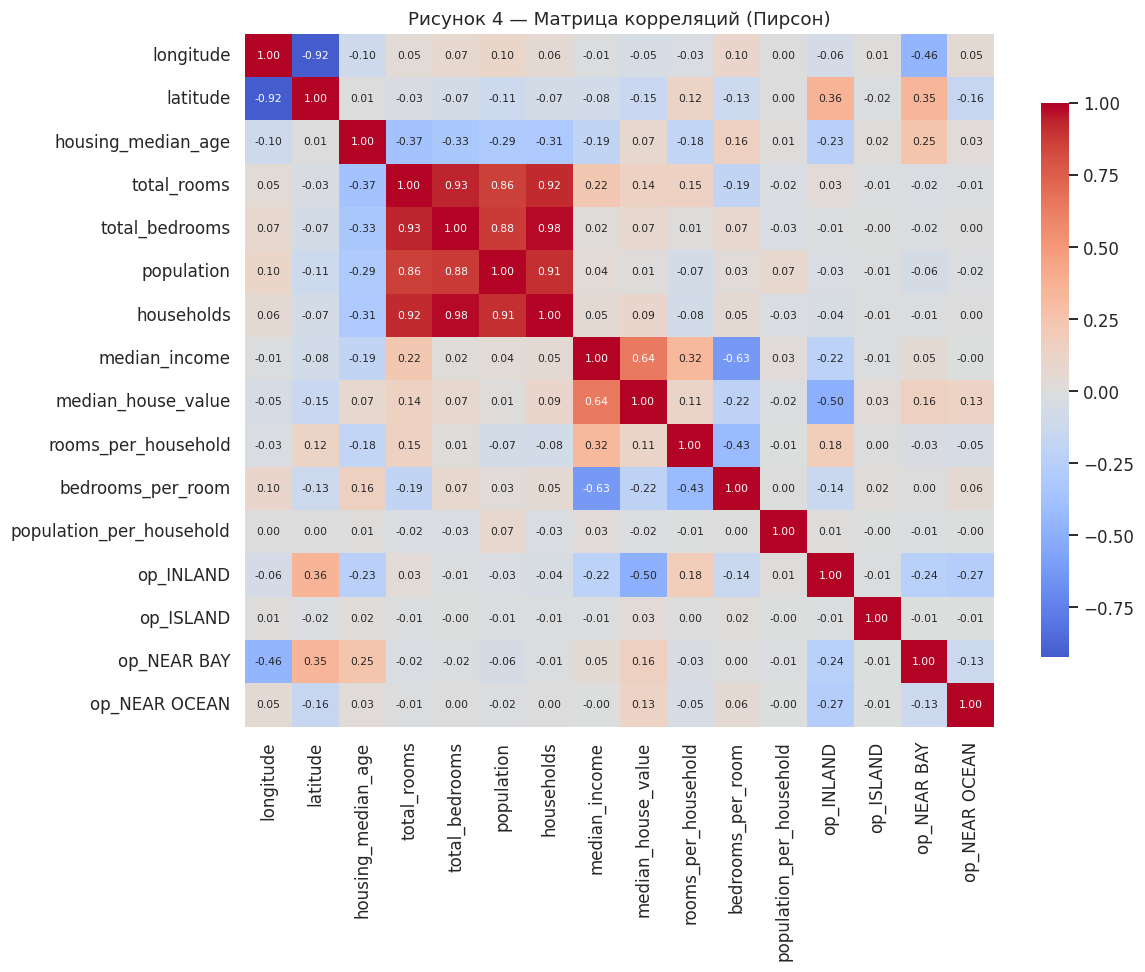

In [12]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Рисунок 4 — Матрица корреляций (Пирсон)")
fig.tight_layout()
plt.show()

In [13]:
# Корреляция каждого признака с целевой переменной, отсортированная по модулю
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Таблица 2 — Корреляция признаков с целевой переменной:")
target_corr.round(3).to_frame("r")

Таблица 2 — Корреляция признаков с целевой переменной:


,r
median_income,0.643
op_INLAND,-0.499
bedrooms_per_room,-0.216
op_NEAR BAY,0.157
latitude,-0.149
total_rooms,0.142
op_NEAR OCEAN,0.135
rooms_per_household,0.109
households,0.094
total_bedrooms,0.075


In [14]:
# Самые сильные пары признак-признак: кандидаты на мультиколлинеарность
cm = corr.drop(index=TARGET, columns=TARGET).abs()
(cm.where(np.triu(np.ones(cm.shape), 1).astype(bool))
   .stack().sort_values(ascending=False).head(6).round(3).to_frame("|r|"))

,,|r|
total_bedrooms,households,0.979
total_rooms,total_bedrooms,0.934
longitude,latitude,0.924
total_rooms,households,0.922
population,households,0.909
total_bedrooms,population,0.879


**Комментарий к рисунку 4 и таблицам.** На тепловой карте отчётливо виден «красный квадрат»
в центре — блок признаков-агрегатов, связанных почти функционально:

- `total_bedrooms` — `households`: r = **0,979**;
- `total_rooms` — `total_bedrooms`: r = 0,934;
- `longitude` — `latitude`: r = −0,924 (вытянутость штата с северо-запада на юго-восток);
- `total_rooms` — `households`: r = 0,922; `population` — `households`: r = 0,909.

Корреляция |r| > 0,9 означает, что признаки практически дублируют друг друга: зная число
домохозяйств, мы почти точно знаем число спален. **Это и есть мультиколлинеарность**, её
количественная оценка — в п. 4.2.

Связь с целевой переменной (таблица 2):

- `median_income` — r = **0,643**: единственный сильный предиктор. Экономически логично —
  цена жилья определяется платёжеспособностью населения района;
- `op_INLAND` — r = **−0,499**: подтверждает вывод по рисунку 3;
- `bedrooms_per_room` — r = −0,216: чем выше доля спален (то есть чем теснее планировка),
  тем дешевле жильё;
- остальные признаки имеют |r| < 0,16, а `population` — всего 0,011.

**Важно:** малая парная корреляция не означает бесполезность признака — в многомерной модели
он может работать в связке с другими (что и подтвердится для `population` и `households`
в п. 4.3).

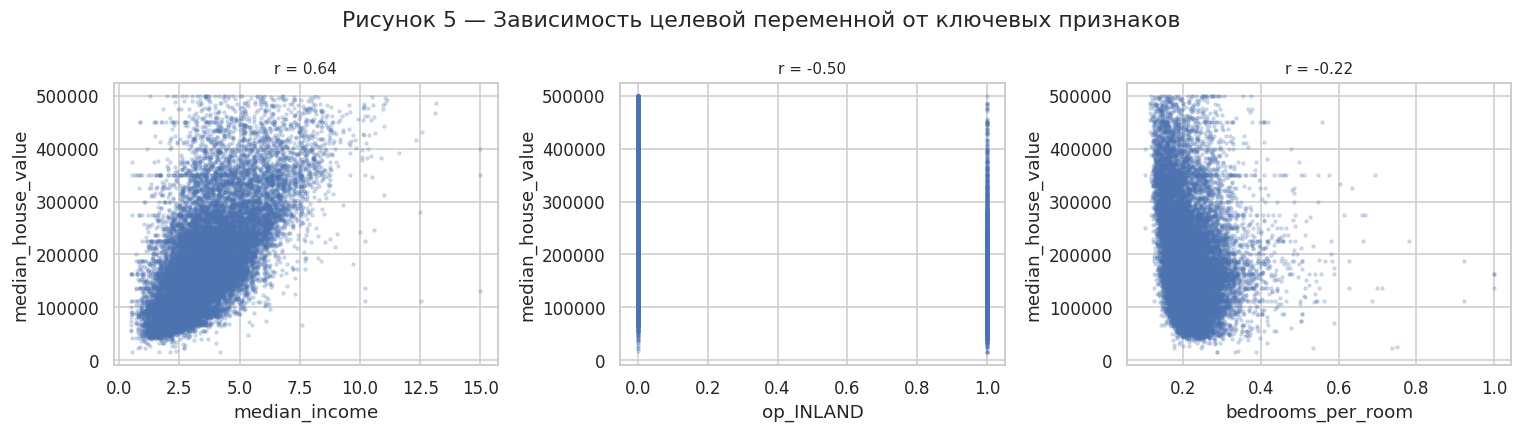

In [15]:
# Диаграммы рассеяния для трёх самых сильных предикторов
top3 = target_corr.abs().sort_values(ascending=False).index[:3]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, top3):
    ax.scatter(df[c], y, s=4, alpha=0.2, color="#4C72B0")
    ax.set_xlabel(c); ax.set_ylabel(TARGET)
    ax.set_title(f"r = {corr.loc[c, TARGET]:.2f}", fontsize=10)
fig.suptitle("Рисунок 5 — Зависимость целевой переменной от ключевых признаков")
fig.tight_layout()
plt.show()

**Комментарий к рисунку 5.**

- *Левый график* (`median_income`): облако точек вытянуто по диагонали — линейная связь
  действительно есть, но разброс **растёт вместе с доходом** (при доходе 2 цены лежат в узком
  коридоре, при доходе 8 — от 150 до 500 тыс. \$). Это первый признак **гетероскедастичности**,
  которая позже подтвердится на рисунке 8.
- *Средний график* (`op_INLAND`): признак бинарный, поэтому точки образуют два столбца;
  видно, что столбец «1» (внутренние районы) целиком смещён вниз.
- *Правый график* (`bedrooms_per_room`): связь слабая и нелинейная, основная масса точек
  сосредоточена в узком диапазоне 0,15–0,25.

**Вывод:** линейная зависимость присутствует, но она не единственная форма связи в данных —
это заранее ограничивает достижимое качество линейных моделей.

<a id="42"></a>
## 4.2. Оценка мультиколлинеарности: коэффициент VIF

Корреляционная матрица показывает только **парные** связи. Признак может быть линейной
комбинацией нескольких других при умеренных парных корреляциях, поэтому используется
фактор инфляции дисперсии:

$$VIF_j = \frac{1}{1 - R_j^2},$$

где $R_j^2$ — коэффициент детерминации регрессии $j$-го признака на все остальные.
Смысл величины: **во сколько раз дисперсия оценки коэффициента больше, чем была бы при
некоррелированных признаках** (стандартная ошибка растёт в $\sqrt{VIF}$ раз).
Пороги: VIF < 5 — нормально, 5 ≤ VIF < 10 — умеренная мультиколлинеарность,
VIF ≥ 10 — сильная.

In [16]:
def vif_table(X_df):
    # VIF_j = 1/(1-R2_j); константа добавляется как свободный член регрессии
    Xs = StandardScaler().fit_transform(X_df)
    Xs = np.column_stack([np.ones(len(Xs)), Xs])
    t = pd.DataFrame({
        "Признак": X_df.columns,
        "VIF": [variance_inflation_factor(Xs, i + 1) for i in range(X_df.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)
    t["Мультиколлинеарность"] = np.where(t.VIF >= 10, "сильная",
                                  np.where(t.VIF >= 5, "умеренная", "нет"))
    return t

print("Таблица 3 — Значения VIF для исходных признаков:")
vif_table(X).round(2)

Таблица 3 — Значения VIF для исходных признаков:


,Признак,VIF,Мультиколлинеарность
0,total_bedrooms,50.92,сильная
1,households,45.64,сильная
2,latitude,20.23,сильная
3,total_rooms,19.46,сильная
4,longitude,18.10,сильная
5,population,7.01,умеренная
6,op_INLAND,2.91,нет
7,bedrooms_per_room,2.85,нет
8,median_income,2.38,нет
9,rooms_per_household,1.84,нет


**Интерпретация таблицы 3.** Результат — **сильная мультиколлинеарность**:

- `total_bedrooms` — VIF = 50,92: дисперсия его коэффициента в 51 раз выше нормальной,
  стандартная ошибка — в √50,92 ≈ **7,1 раза**;
- `households` — 45,64; `latitude` — 20,23; `total_rooms` — 19,46; `longitude` — 18,10 —
  все выше порога 10;
- `population` — 7,01 — умеренная;
- остальные девять признаков (включая `median_income` — 2,38) в норме.

**Практические последствия:** оценки коэффициентов при коррелированных признаках становятся
неустойчивыми — они могут менять знак и величину при малом изменении выборки, поэтому
**интерпретировать их по отдельности нельзя**. При этом на *точность прогноза* мультиколлинеарность
влияет слабо: модель в целом остаётся состоятельной. Именно поэтому далее проверяются два способа
борьбы с ней — регуляризация (Ridge/Lasso) и переход к ортогональным компонентам (PCA).

<a id="43"></a>
## 4.3. Регрессионные модели на исходных признаках

Строятся три модели, различающиеся видом штрафа за величину коэффициентов:

| Модель | Минимизируемый функционал | Поведение |
|---|---|---|
| **МНК** (`LinearRegression`) | $\sum (y_i-\hat y_i)^2$ | без штрафа; при мультиколлинеарности оценки неустойчивы |
| **Ridge** ($L_2$) | $\sum (y_i-\hat y_i)^2 + \alpha\sum \beta_j^2$ | сжимает коэффициенты, **не обнуляя** их; стабилизирует оценки коррелированных признаков |
| **Lasso** ($L_1$) | $\sum (y_i-\hat y_i)^2 + \alpha\sum |\beta_j|$ | часть коэффициентов **обнуляется** — выполняется автоматический отбор признаков |

Параметр $\alpha$ подбирается поиском по сетке из 40 значений с 5-блочной кросс-валидацией.

In [17]:
def evaluate(model, Xtr, ytr, Xte, yte, name, store):
    # Обучает модель и считает RMSE, MAE, R2, скорректированный R2, MAPE и CV-оценки
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    n, k = Xte.shape[0], Xtr.shape[1]                 # объём теста и число признаков
    r2 = r2_score(yte, pred)
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_r2 = cross_val_score(model, Xtr, ytr, cv=cv, scoring="r2")
    cv_rmse = -cross_val_score(model, Xtr, ytr, cv=cv, scoring="neg_root_mean_squared_error")
    row = {"Модель": name,
           "RMSE": np.sqrt(mean_squared_error(yte, pred)),
           "MAE": mean_absolute_error(yte, pred),
           "R2": r2,
           "R2 adj": 1 - (1 - r2) * (n - 1) / (n - k - 1),   # штраф за число признаков
           "MAPE, %": mean_absolute_percentage_error(yte, pred) * 100,
           "CV R2": cv_r2.mean(),
           "CV R2 std": cv_r2.std(),                          # разброс по блокам = устойчивость
           "CV RMSE": cv_rmse.mean()}
    store.append(row)
    print(f"{name}:\n  RMSE = {row['RMSE']:.0f} $   MAE = {row['MAE']:.0f} $   "
          f"R2 = {row['R2']:.4f}   MAPE = {row['MAPE, %']:.2f} %   "
          f"CV R2 = {row['CV R2']:.4f} ± {row['CV R2 std']:.4f}")
    return row, pred

def tune(model, grid, Xtr, ytr):
    # Подбор alpha по сетке с 5-блочной кросс-валидацией (метрика — R2)
    gs = GridSearchCV(model, grid, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                      scoring="r2").fit(Xtr, ytr)
    return gs.best_params_["alpha"]

results = []
lin = LinearRegression()
row_lin, pred_lin = evaluate(lin, X_train_s, y_train, X_test_s, y_test,
                             "Линейная регрессия (исходные)", results)

Линейная регрессия (исходные):
  RMSE = 60019 $   MAE = 43965 $   R2 = 0.6281   MAPE = 26.88 %   CV R2 = 0.6138 ± 0.0189


In [18]:
# Гребневая регрессия: подбираем alpha, затем обучаем с лучшим значением
alpha_ridge = tune(Ridge(), {"alpha": np.logspace(-3, 4, 40)}, X_train_s, y_train)
print("Оптимальное alpha (Ridge):", round(alpha_ridge, 2), "\n")
ridge = Ridge(alpha=alpha_ridge)
row_ridge, pred_ridge = evaluate(ridge, X_train_s, y_train, X_test_s, y_test,
                                 "Гребневая регрессия (исходные)", results)

Оптимальное alpha (Ridge): 70.17 

Гребневая регрессия (исходные):
  RMSE = 60038 $   MAE = 43925 $   R2 = 0.6278   MAPE = 26.76 %   CV R2 = 0.6143 ± 0.0176


In [19]:
# Лассо-регрессия: L1-штраф обнуляет часть коэффициентов
alpha_lasso = tune(Lasso(max_iter=10000), {"alpha": np.logspace(-2, 4, 40)}, X_train_s, y_train)
print("Оптимальное alpha (Lasso):", round(alpha_lasso, 2), "\n")
lasso = Lasso(alpha=alpha_lasso, max_iter=10000)
row_lasso, pred_lasso = evaluate(lasso, X_train_s, y_train, X_test_s, y_test,
                                 "Лассо-регрессия (исходные)", results)

lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
zeroed = list(lasso_coefs[lasso_coefs == 0].index)
print(f"\nLasso обнулил {len(zeroed)} признаков из {len(lasso_coefs)}: {zeroed}")

Оптимальное alpha (Lasso): 289.43 

Лассо-регрессия (исходные):
  RMSE = 60054 $   MAE = 43910 $   R2 = 0.6276   MAPE = 26.68 %   CV R2 = 0.6152 ± 0.0164

Lasso обнулил 2 признаков из 15: ['total_rooms', 'population_per_household']


In [20]:
print("Таблица 4 — Качество моделей на исходных признаках:")
pd.DataFrame(results).round(4)

Таблица 4 — Качество моделей на исходных признаках:


,Модель,RMSE,MAE,R2,R2 adj,"MAPE, %",CV R2,CV R2 std,CV RMSE
0,Линейная регрессия (исходные),60019.2578,43964.6510,0.6281,0.6266,26.8798,0.6138,0.0189,60574.0654
1,Гребневая регрессия (исходные),60038.2189,43924.9733,0.6278,0.6264,26.7571,0.6143,0.0176,60536.1986
2,Лассо-регрессия (исходные),60053.6506,43910.1732,0.6276,0.6262,26.6763,0.6152,0.0164,60466.9800


**Интерпретация таблицы 4 — что означает каждое число.**

**R² = 0,6281** (линейная регрессия). Модель объясняет **62,8 % разброса** цен, остальные 37,2 %
остаются необъяснёнными. Хорошо это или плохо? По принятым в эконометрике ориентирам для
социально-экономических данных значение 0,5–0,7 считается **умеренным, приемлемым** результатом
(для технических измерений ожидали бы > 0,9, для поведенческих данных и 0,3 было бы неплохо).
Однако на этом же датасете нелинейные модели (случайный лес, градиентный бустинг) дают
R² ≈ 0,80–0,85 — значит, **0,63 — это потолок линейной формы зависимости**, а не потолок данных.
Вывод: результат удовлетворительный, но модель заведомо упрощает реальную зависимость.

**R² adj = 0,6266** — практически совпадает с R² (разница 0,0015). Скорректированный R² штрафует
за число признаков; столь малая разница означает, что **лишних, бесполезных признаков в модели
почти нет** — при 15 предикторах и 15 580 наблюдениях штраф ничтожен.

**RMSE = 60 019 \$.** Сравниваем с σ(y) = 97 703 \$: отношение RMSE/σ = 0,61, то есть модель
ошибается **на 39 % меньше**, чем тривиальный прогноз «всегда средняя цена». В относительном
выражении RMSE составляет 31 % от средней цены (192 445 \$) — ошибка велика для практического
применения (оценщик недвижимости с такой точностью работать не станет), но для учебной линейной
модели закономерна.

**MAE = 43 965 \$** заметно меньше RMSE. RMSE возводит ошибки в квадрат и потому чувствителен
к крупным промахам; разрыв в **16 тыс. \$ (36 %)** означает, что средняя ошибка умеренная,
но существует группа наблюдений с очень большими ошибками (дорогое жильё — см. рисунок 8).

**MAPE = 26,88 %.** По шкале Льюиса это **удовлетворительная точность** (диапазон 20–50 %).
Прогноз в среднем отклоняется от факта на четверть стоимости. Заметим, что MAPE несимметрична
и сильнее штрафует занижение у дешёвого жилья, поэтому для кварталов с низкой ценой
относительная ошибка выше средней.

**CV R² = 0,6138 ± 0,0189.** Среднее по 5 блокам кросс-валидации почти совпадает с R² на
отложенном тесте (0,6281), а стандартное отклонение по блокам мало (0,019 = 3 % от величины).
Это означает **отсутствие переобучения и устойчивость модели**: качество не зависит от того,
какая часть данных попала в обучение. Небольшое превышение тестового R² над CV объясняется тем,
что при кросс-валидации модель обучается на 4/5 данных, то есть на меньшем объёме.

**Сравнение трёх моделей.** Разница между МНК, Ridge и Lasso лежит в пределах 0,0005 по R²
и 35 \$ по RMSE — то есть **статистически неразличима**. Причина: объём выборки (15 580)
в тысячу раз превышает число признаков (15), дисперсия оценок мала и регуляризация почти
не влияет на прогноз. При этом Lasso показал **лучший CV R² (0,6152) и лучший MAPE (26,68 %)**,
а Ridge — лучший CV RMSE, то есть регуляризация всё же слегка повышает устойчивость.

**Отдельный результат Lasso:** при α = 289,4 обнулены два признака — `total_rooms`
и `population_per_household`. Качество при этом не упало, значит **эти признаки не несут
уникальной информации**: `total_rooms` почти полностью дублируется парой
`total_bedrooms` + `households` (r = 0,93 и 0,92), а `population_per_household` слабо связан
с ценой (r = −0,021). Lasso автоматически выполнил отбор признаков — это его практическое
преимущество перед Ridge.

In [21]:
# Коэффициенты трёх моделей в одной таблице (значения — в долларах на 1 ст. отклонение признака)
cmp = pd.DataFrame({"МНК": lin.coef_, "Ridge": ridge.coef_, "Lasso": lasso.coef_},
                   index=X.columns)
cmp["|МНК|"] = cmp["МНК"].abs()
cmp = cmp.sort_values("|МНК|", ascending=False).drop(columns="|МНК|")
print("Таблица 5 — Коэффициенты моделей на стандартизованных признаках:")
cmp.round(1)

Таблица 5 — Коэффициенты моделей на стандартизованных признаках:


,МНК,Ridge,Lasso
median_income,64792.3,64635.0,64687.5
longitude,-50834.6,-44412.7,-41704.9
latitude,-49234.7,-42429.6,-39833.3
population,-37533.3,-35632.4,-33901.4
households,29904.3,26287.2,25021.9
op_INLAND,-15983.4,-17810.6,-18202.5
bedrooms_per_room,14428.3,14067.5,13636.2
total_bedrooms,12350.1,13943.6,13899.4
housing_median_age,12156.6,12192.4,11820.9
rooms_per_household,4567.3,3967.3,3402.8


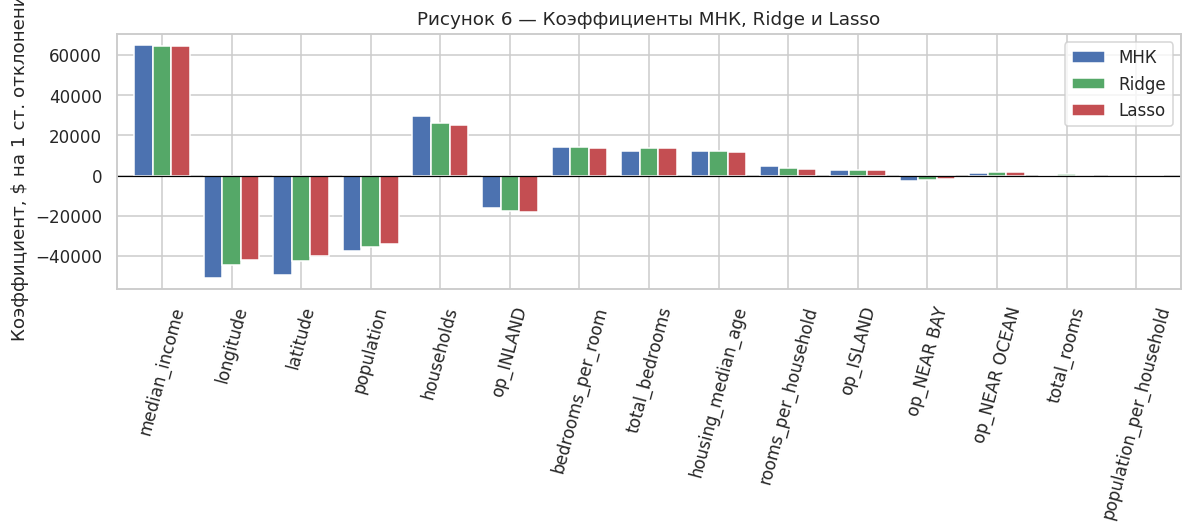

In [22]:
fig, ax = plt.subplots(figsize=(11, 5))
cmp.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52"], width=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Коэффициент, $ на 1 ст. отклонение")
ax.set_title("Рисунок 6 — Коэффициенты МНК, Ridge и Lasso")
ax.tick_params(axis="x", rotation=75)
fig.tight_layout()
plt.show()

**Комментарий к рисунку 6 и таблице 5.** Так как признаки стандартизованы, коэффициенты
сопоставимы между собой и читаются как «прирост цены при увеличении признака на одно
стандартное отклонение».

- `median_income` = +64 792 \$ — самый сильный эффект и единственный, который можно уверенно
  интерпретировать содержательно (VIF = 2,38, мультиколлинеарностью не искажён);
- `longitude` = −50 835 \$ и `latitude` = −49 235 \$ — движение на север и на восток удешевляет
  жильё; но VIF этих признаков ≈ 20, поэтому конкретные величины ненадёжны;
- **`population` = −37 533 \$ при `households` = +29 904 \$** — самая показательная аномалия.
  Парные корреляции обоих признаков с ценой положительны и близки к нулю, но в модели они
  получили большие противоположные знаки. Это **классический симптом мультиколлинеарности**:
  сильно связанные признаки (r = 0,909) «делят» общий эффект, и модель фактически использует
  их разность — плотность заселения домохозяйства. Отдельно такие коэффициенты интерпретировать
  бессмысленно;
- столбцы Ridge и Lasso на графике **везде ниже** столбцов МНК по модулю — это и есть эффект
  сжатия коэффициентов. У Lasso два столбца (`total_rooms`, `population_per_household`)
  обнулены полностью.

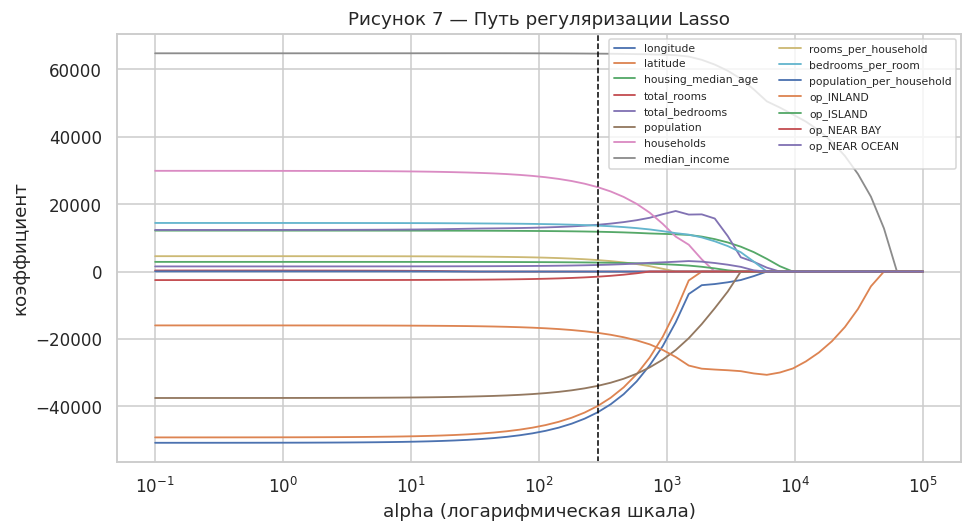

In [23]:
# Путь регуляризации: как коэффициенты гаснут с ростом alpha
alphas = np.logspace(-1, 5, 60)
paths = np.array([Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train).coef_ for a in alphas])
fig, ax = plt.subplots(figsize=(9, 5))
for j, name in enumerate(X.columns):
    ax.plot(alphas, paths[:, j], label=name, lw=1.2)
ax.set_xscale("log")
ax.axvline(alpha_lasso, ls="--", color="black", lw=1)   # выбранное кросс-валидацией значение
ax.set_xlabel("alpha (логарифмическая шкала)"); ax.set_ylabel("коэффициент")
ax.set_title("Рисунок 7 — Путь регуляризации Lasso")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

**Комментарий к рисунку 7.** График показывает, как меняются коэффициенты при усилении штрафа.
Чёрная пунктирная линия — выбранное кросс-валидацией α = 289. Слева от неё коэффициенты почти
равны оценкам МНК; справа они один за другим «схлопываются» в ноль, и при α > 10⁴ модель
вырождается в константу (прогноз = среднее). Первыми обнуляются слабые и дублирующие признаки,
дольше всех — `median_income`: он остаётся ненулевым почти до самого конца, что ещё раз
подтверждает его роль главного предиктора.

<a id="44"></a>
## 4.4. Диагностика остатков

Проверяем выполнение предпосылок линейной регрессии: несмещённость (среднее остатков ≈ 0),
гомоскедастичность (постоянство разброса) и нормальность остатков.

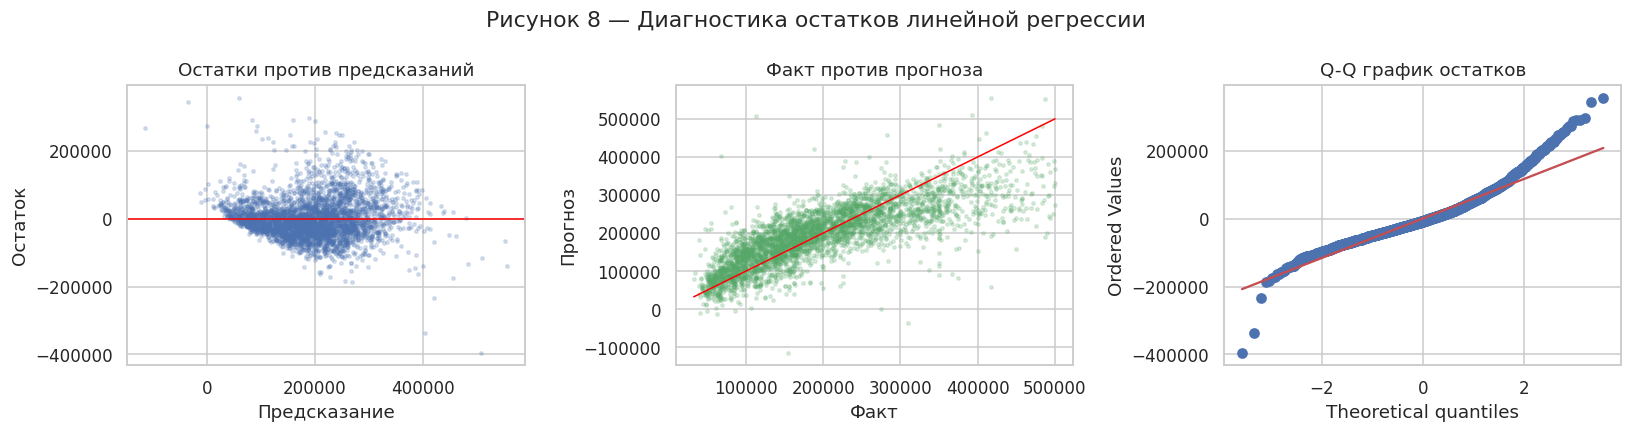

Среднее остатков: 872.9 $ (должно быть ≈ 0)
Асимметрия остатков: 0.91   Эксцесс: 3.30


In [24]:
resid = y_test - pred_lin      # остатки = факт минус прогноз
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(pred_lin, resid, s=5, alpha=0.2, color="#4C72B0")
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("Предсказание"); axes[0].set_ylabel("Остаток")
axes[0].set_title("Остатки против предсказаний")
axes[1].scatter(y_test, pred_lin, s=5, alpha=0.2, color="#55A868")
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, color="red", lw=1)     # линия идеального прогноза
axes[1].set_xlabel("Факт"); axes[1].set_ylabel("Прогноз")
axes[1].set_title("Факт против прогноза")
stats.probplot(resid, dist="norm", plot=axes[2])  # Q-Q график: проверка нормальности остатков
axes[2].set_title("Q-Q график остатков")
fig.suptitle("Рисунок 8 — Диагностика остатков линейной регрессии")
fig.tight_layout()
plt.show()

print(f"Среднее остатков: {resid.mean():.1f} $ (должно быть ≈ 0)")
print(f"Асимметрия остатков: {resid.skew():.2f}   Эксцесс: {resid.kurtosis():.2f}")

**Комментарий к рисунку 8 — по каждой панели.**

*Левая панель (остатки против предсказаний).* Идеальная картина — бесструктурное горизонтальное
облако. Здесь же облако **расширяется вправо**: при прогнозе 100 тыс. \$ остатки лежат в пределах
±50 тыс., при прогнозе 350 тыс. \$ — уже ±150 тыс. Это **гетероскедастичность** — дисперсия
ошибки зависит от уровня цены. Следствие: точечные прогнозы остаются несмещёнными, но
стандартные ошибки коэффициентов и доверительные интервалы рассчитаны неверно (занижены).
Видна и характерная диагональная граница снизу — артефакт неотрицательности цен.

*Средняя панель (факт против прогноза).* Красная линия — идеальное совпадение. Облако точек
систематически лежит **ниже** линии в правой части: для дорогого жилья (> 350 тыс. \$) модель
**занижает** прогноз. Причина — линейная форма модели не успевает за ускоренным ростом цен
в премиальном сегменте.

*Правая панель (Q-Q график).* При нормальных остатках точки должны лечь на прямую. Здесь
центральная часть совпадает с прямой, но **оба конца отклоняются вверх**, особенно правый —
это тяжёлый правый хвост. Численно: асимметрия остатков 0,91, эксцесс 3,30 (у нормального
распределения оба показателя равны 0). Среднее остатков 873 \$ при масштабе цен 200 тыс. \$ —
практически ноль, то есть **систематического смещения в целом нет**.

**Итоговый вывод по диагностике:** нарушены предпосылки гомоскедастичности и нормальности
остатков. Это не делает модель бесполезной (оценки МНК остаются состоятельными), но означает,
что (а) строить по ней доверительные интервалы некорректно, (б) для повышения качества нужно
логарифмировать целевую переменную или переходить к нелинейным моделям.

<a id="45"></a>
## 4.5. Устранение мультиколлинеарности: метод главных компонент

PCA строит новые признаки — линейные комбинации исходных, взаимно **ортогональные** и
упорядоченные по убыванию объясняемой дисперсии. Поскольку метод основан на матрице ковариаций
и чувствителен к масштабу, данные предварительно стандартизованы (см. раздел 3).

In [25]:
pca_full = PCA().fit(X_train_s)                  # PCA на всех компонентах для анализа дисперсии
evr = pca_full.explained_variance_ratio_         # доля дисперсии каждой компоненты
cum = np.cumsum(evr)                             # накопленная доля
n_comp = int(np.argmax(cum >= 0.95) + 1)         # критерий 95 % объяснённой дисперсии
n_kaiser = int((pca_full.explained_variance_ > 1).sum())   # критерий Кайзера (собств. знач. > 1)

print(f"Компонент по критерию 95 % дисперсии: {n_comp}")
print(f"Компонент по критерию Кайзера (СЗ > 1): {n_kaiser}")
print("\nТаблица 6 — Объяснённая дисперсия главных компонент:")
pd.DataFrame({"Компонента": [f"PC{i+1}" for i in range(len(evr))],
              "Собств. значение": pca_full.explained_variance_.round(3),
              "Доля дисперсии": evr.round(4),
              "Накопленная доля": cum.round(4)})

Компонент по критерию 95 % дисперсии: 10
Компонент по критерию Кайзера (СЗ > 1): 6

Таблица 6 — Объяснённая дисперсия главных компонент:


,Компонента,Собств. значение,Доля дисперсии,Накопленная доля
0,PC1,3.953,0.2635,0.2635
1,PC2,2.331,0.1554,0.4189
2,PC3,1.974,0.1316,0.5505
3,PC4,1.521,0.1014,0.6520
4,PC5,1.012,0.0675,0.7194
5,PC6,1.006,0.0671,0.7865
6,PC7,0.972,0.0648,0.8513
7,PC8,0.715,0.0477,0.8989
8,PC9,0.626,0.0417,0.9407
9,PC10,0.430,0.0287,0.9694


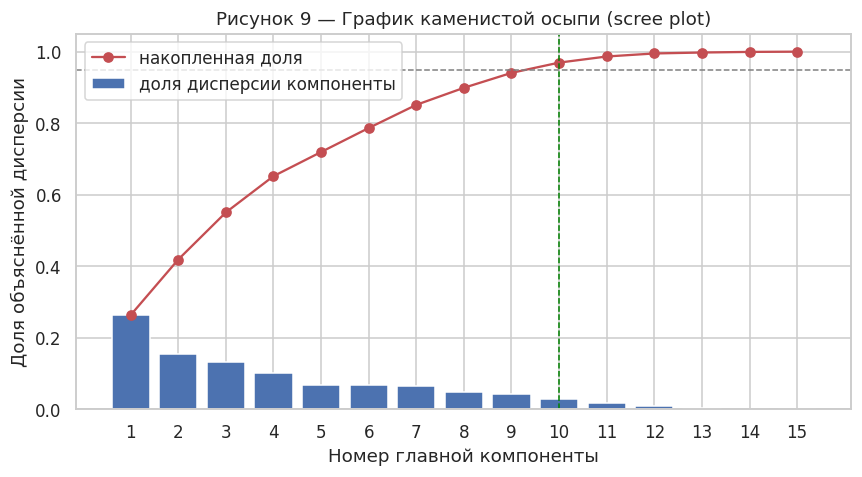

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xs = np.arange(1, len(evr) + 1)
ax.bar(xs, evr, color="#4C72B0", label="доля дисперсии компоненты")
ax.plot(xs, cum, "o-", color="#C44E52", label="накопленная доля")
ax.axhline(0.95, ls="--", color="gray", lw=1)      # порог 95 %
ax.axvline(n_comp, ls="--", color="green", lw=1)   # выбранное число компонент
ax.set_xlabel("Номер главной компоненты"); ax.set_ylabel("Доля объяснённой дисперсии")
ax.set_title("Рисунок 9 — График каменистой осыпи (scree plot)")
ax.set_xticks(xs); ax.legend()
fig.tight_layout()
plt.show()

**Комментарий к рисунку 9 (график каменистой осыпи).** Столбцы — вклад каждой компоненты,
красная линия — накопленная доля дисперсии.

- Первая компонента объясняет **26,4 %** дисперсии, вторая — 15,5 %, третья — 13,2 %,
  четвёртая — 10,1 %; далее вклад падает до 6–7 % и ниже. Резкого доминирования одной компоненты
  нет — информация распределена по нескольким направлениям.
- **«Локоть»** (точка, после которой кривая выполаживается) приходится на 4–5 компоненту:
  после неё столбцы почти одинаковы по высоте.
- **Критерий Кайзера** (собственное значение > 1) даёт 6 компонент: у PC1–PC6 собственные
  значения 3,95; 2,33; 1,97; 1,52; 1,01; 1,01, у PC7 — уже 0,97.
- **Критерий 95 % накопленной дисперсии** (использован в работе, зелёная линия) даёт
  **10 компонент**: размерность снижается с 15 до 10 при потере 5 % информации.

Последние компоненты (PC13–PC15) имеют собственные значения 0,04; 0,03; 0,01 — это направления,
вдоль которых данные практически не изменяются, то есть **прямое численное выражение
мультиколлинеарности**: почти нулевое собственное значение означает существование почти линейной
зависимости между признаками.

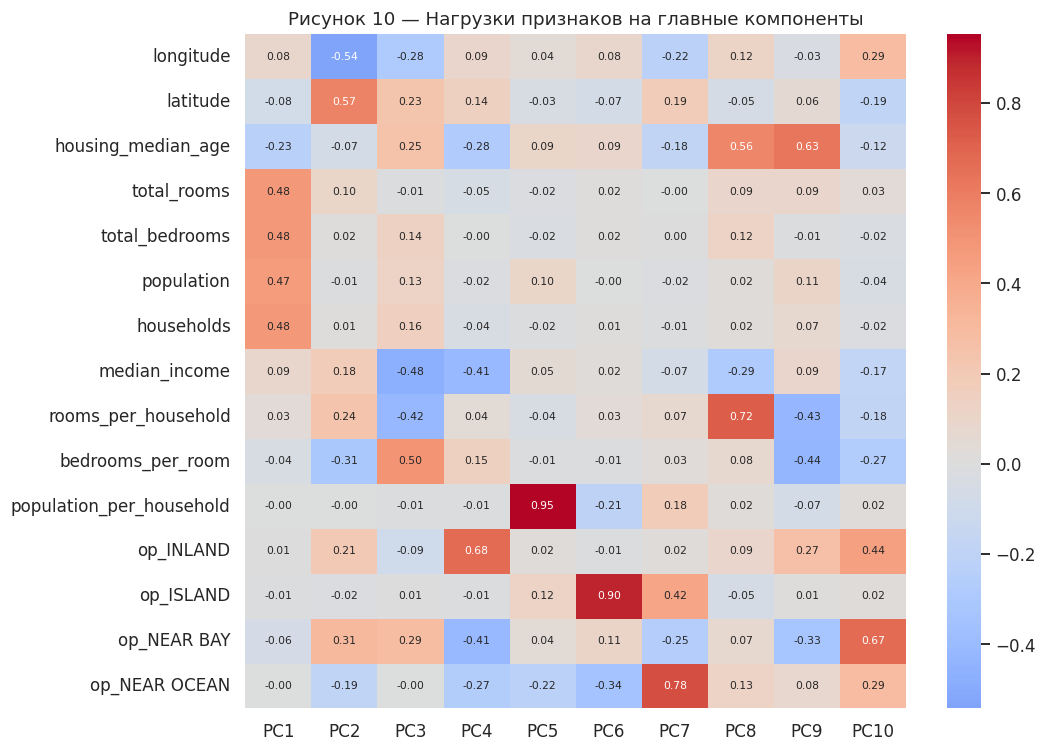

In [27]:
# Обучаем PCA на выбранном числе компонент и смотрим, из чего они составлены
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE).fit(X_train_s)
X_train_p = pca.transform(X_train_s)
X_test_p = pca.transform(X_test_s)

loadings = pd.DataFrame(pca.components_.T, index=X.columns,
                        columns=[f"PC{i+1}" for i in range(n_comp)])
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Рисунок 10 — Нагрузки признаков на главные компоненты")
fig.tight_layout()
plt.show()

In [28]:
# Проверка: компоненты ортогональны, поэтому VIF должен стать равен 1
print("VIF главных компонент:")
vif_table(pd.DataFrame(X_train_p, columns=loadings.columns)).round(3)

VIF главных компонент:


,Признак,VIF,Мультиколлинеарность
0,PC1,1.0,нет
1,PC3,1.0,нет
2,PC10,1.0,нет
3,PC4,1.0,нет
4,PC9,1.0,нет
5,PC8,1.0,нет
6,PC2,1.0,нет
7,PC5,1.0,нет
8,PC6,1.0,нет
9,PC7,1.0,нет


**Комментарий к рисунку 10 (матрица нагрузок).** Нагрузка — вклад исходного признака в
компоненту; чем ярче ячейка, тем сильнее связь. Содержательная расшифровка первых компонент:

- **PC1 (26,4 %)** — высокие нагрузки у `total_rooms`, `total_bedrooms`, `population`,
  `households` (≈ 0,45 каждая). Это обобщённый **«размер квартала»**: именно тот блок признаков,
  который давал VIF 20–51. PCA свернул четыре дублирующих признака в один фактор;
- **PC2 (15,5 %)** — противоположные по знаку нагрузки `longitude` и `latitude`,
  плюс `op_INLAND` — **географический фактор** «побережье — внутренние районы»;
- **PC3 (13,2 %)** — `bedrooms_per_room`, `rooms_per_household`, `median_income` —
  фактор **структуры и качества жилья**;
- дальнейшие компоненты смешивают оставшиеся признаки и не имеют простой интерпретации.

**Главный результат:** VIF всех десяти компонент равен **1,00** (таблица выше) — это точное
значение, следующее из ортогональности компонент. **Мультиколлинеарность устранена полностью.**

<a id="46"></a>
## 4.6. Регрессия на главных компонентах и сравнение моделей

Те же три модели обучаются заново, но признаками служат 10 главных компонент.

In [29]:
# Те же три модели, но на главных компонентах
evaluate(LinearRegression(), X_train_p, y_train, X_test_p, y_test,
         f"Линейная регрессия (PCA-{n_comp})", results)

alpha_ridge_p = tune(Ridge(), {"alpha": np.logspace(-3, 4, 40)}, X_train_p, y_train)
evaluate(Ridge(alpha=alpha_ridge_p), X_train_p, y_train, X_test_p, y_test,
         f"Гребневая регрессия (PCA-{n_comp})", results)

alpha_lasso_p = tune(Lasso(max_iter=10000), {"alpha": np.logspace(-2, 4, 40)}, X_train_p, y_train)
evaluate(Lasso(alpha=alpha_lasso_p, max_iter=10000), X_train_p, y_train, X_test_p, y_test,
         f"Лассо-регрессия (PCA-{n_comp})", results)

print(f"\nOптимальные alpha после PCA: Ridge = {alpha_ridge_p:.1f}, Lasso = {alpha_lasso_p:.1f}")

Линейная регрессия (PCA-10):
  RMSE = 66711 $   MAE = 49246 $   R2 = 0.5405   MAPE = 29.19 %   CV R2 = 0.5216 ± 0.0146


Гребневая регрессия (PCA-10):
  RMSE = 66724 $   MAE = 49270 $   R2 = 0.5403   MAPE = 29.29 %   CV R2 = 0.5219 ± 0.0135


Лассо-регрессия (PCA-10):
  RMSE = 66762 $   MAE = 49321 $   R2 = 0.5398   MAPE = 29.36 %   CV R2 = 0.5232 ± 0.0119

Oптимальные alpha после PCA: Ridge = 366.5, Lasso = 587.8


In [30]:
metrics = pd.DataFrame(results).round(4)
print("Таблица 7 — Сравнение качества всех шести моделей:")
metrics

Таблица 7 — Сравнение качества всех шести моделей:


,Модель,RMSE,MAE,R2,R2 adj,"MAPE, %",CV R2,CV R2 std,CV RMSE
0,Линейная регрессия (исходные),60019.2578,43964.6510,0.6281,0.6266,26.8798,0.6138,0.0189,60574.0654
1,Гребневая регрессия (исходные),60038.2189,43924.9733,0.6278,0.6264,26.7571,0.6143,0.0176,60536.1986
2,Лассо-регрессия (исходные),60053.6506,43910.1732,0.6276,0.6262,26.6763,0.6152,0.0164,60466.9800
3,Линейная регрессия (PCA-10),66711.2136,49245.8494,0.5405,0.5393,29.1910,0.5216,0.0146,67436.0946
4,Гребневая регрессия (PCA-10),66724.3067,49269.6512,0.5403,0.5391,29.2925,0.5219,0.0135,67415.6595
5,Лассо-регрессия (PCA-10),66761.9086,49320.9528,0.5398,0.5386,29.3566,0.5232,0.0119,67327.0109


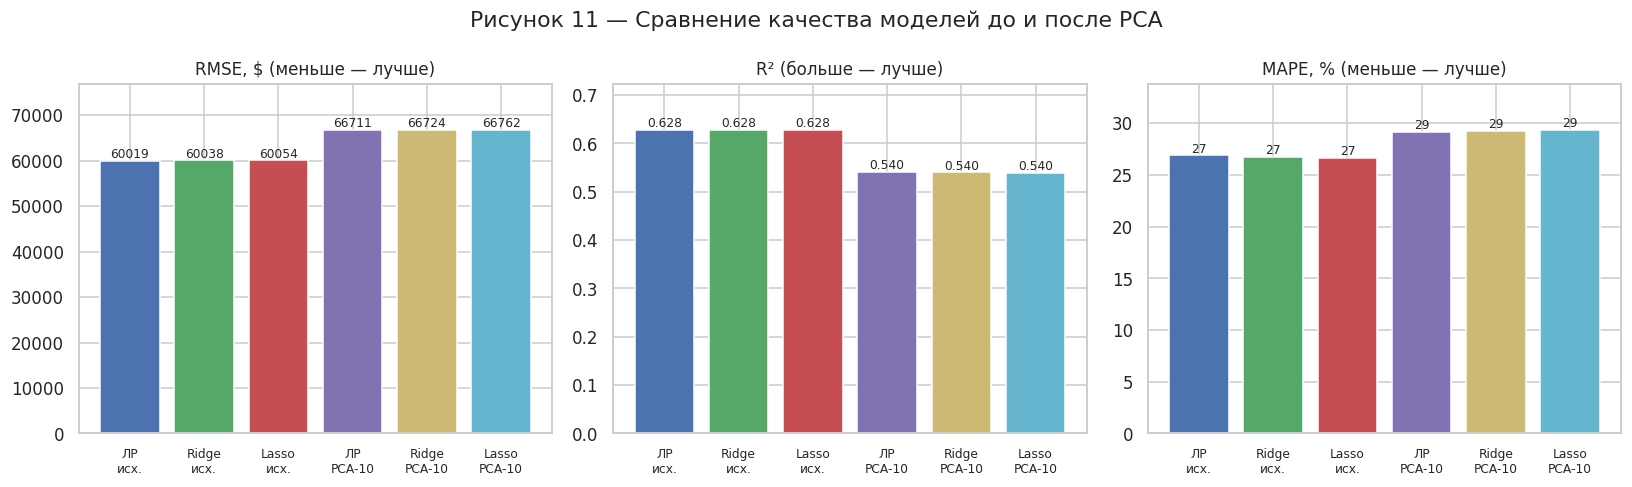

In [31]:
short = ["ЛР\nисх.", "Ridge\nисх.", "Lasso\nисх.",
         f"ЛР\nPCA-{n_comp}", f"Ridge\nPCA-{n_comp}", f"Lasso\nPCA-{n_comp}"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, ttl in zip(axes, ["RMSE", "R2", "MAPE, %"],
                        ["RMSE, $ (меньше — лучше)", "R² (больше — лучше)",
                         "MAPE, % (меньше — лучше)"]):
    bars = ax.bar(short, metrics[col], color=colors)
    ax.bar_label(bars, fmt="%.3f" if col == "R2" else "%.0f", fontsize=8)
    ax.set_title(ttl, fontsize=11); ax.margins(y=0.15)
    ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Рисунок 11 — Сравнение качества моделей до и после PCA")
fig.tight_layout()
plt.show()

**Комментарий к рисунку 11 и таблице 7.** Три левых столбца (исходные признаки) и три правых
(после PCA) образуют две чётко различающиеся группы:

| Показатель | До PCA (ЛР) | После PCA (ЛР) | Изменение |
|---|---|---|---|
| RMSE, \$ | 60 019 | 66 711 | **+11,1 %** (хуже) |
| MAE, \$ | 43 965 | 49 246 | +12,0 % (хуже) |
| R² | 0,6281 | 0,5405 | **−0,088** (хуже) |
| MAPE, % | 26,88 | 29,19 | +2,31 п. п. (хуже) |
| CV R² std | 0,0189 | 0,0146 | −23 % (лучше: устойчивее) |

Внутри каждой группы МНК, Ridge и Lasso по-прежнему неразличимы (разброс R² в четвёртом знаке).

**Что это значит.** R² после PCA упал с 0,63 до 0,54 — модель стала объяснять на 8,8 п. п.
дисперсии меньше, а средняя ошибка выросла на 6,7 тыс. \$. Это **ухудшение**, и оно закономерно:
PCA — метод обучения **без учителя**, он максимизирует объяснённую дисперсию *признаков*,
ничего не зная о целевой переменной. Отбрасывая 5 % «наименее изменчивой» информации, мы
не имеем гарантии, что эта информация бесполезна для прогноза цены.

Единственное, что улучшилось, — **устойчивость**: разброс R² по блокам кросс-валидации
снизился с 0,0189 до 0,0146, что и ожидается после устранения мультиколлинеарности.

Проверим напрямую, какие именно компоненты полезны для прогноза.

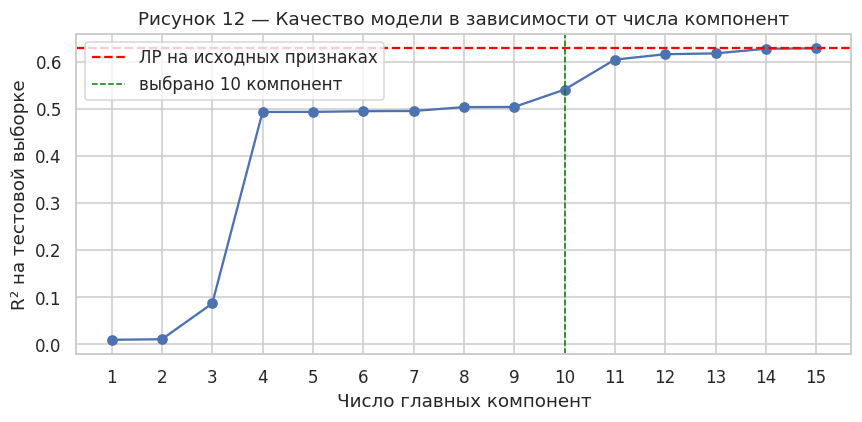

R² по числу компонент: [0.01  0.011 0.087 0.493 0.493 0.495 0.495 0.503 0.504 0.54  0.604 0.616
 0.617 0.627 0.628]


In [32]:
# Наращиваем число компонент от 1 до 15 и смотрим, как растёт R2 на тесте
scores = []
for k in range(1, X_train_s.shape[1] + 1):
    p = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train_s)
    m = LinearRegression().fit(p.transform(X_train_s), y_train)
    scores.append(r2_score(y_test, m.predict(p.transform(X_test_s))))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(scores) + 1), scores, "o-", color="#4C72B0")
ax.axhline(row_lin["R2"], ls="--", color="red", label="ЛР на исходных признаках")
ax.axvline(n_comp, ls="--", color="green", lw=1, label=f"выбрано {n_comp} компонент")
ax.set_xlabel("Число главных компонент"); ax.set_ylabel("R² на тестовой выборке")
ax.set_title("Рисунок 12 — Качество модели в зависимости от числа компонент")
ax.legend(); ax.set_xticks(range(1, len(scores) + 1))
fig.tight_layout()
plt.show()

print("R² по числу компонент:", np.round(scores, 3))

**Комментарий к рисунку 12 — ключевой график работы.** Рост качества идёт не плавно,
а **тремя скачками**:

- PC1–PC3 дают R² всего **0,087**, хотя объясняют 55 % дисперсии признаков — обобщённый «размер
  квартала» почти бесполезен для прогноза цены;
- 4-я компонента даёт скачок **до 0,493** — именно она содержит доход и географию;
- компоненты 5–10 добавляют лишь +0,047 (до 0,540) — это уровень, полученный в п. 4.6;
- **11-я компонента даёт +0,064** (0,540 → 0,604), хотя объясняет менее 2 % дисперсии признаков;
- 14-я добавляет ещё +0,010, и лишь на всех 15 компонентах модель полностью повторяет результат
  регрессии на исходных признаках (R² = 0,628) — что математически закономерно, так как полный
  набор компонент является невырожденным линейным преобразованием исходных признаков.

**Вывод:** ценность компоненты для *прогноза* не связана с её долей дисперсии *признаков*.
Критерий «95 % дисперсии» отбросил как раз ту (11-ю) компоненту, которая была одной из самых
полезных. Это главная содержательная находка работы и прямое объяснение падения качества
после PCA.

<a id="5"></a>
# 5. Заключение

В ходе работы на реальном датасете **California Housing Prices** (20 640 наблюдений) построены
и исследованы шесть регрессионных моделей и выполнено снижение размерности методом главных
компонент. Получены следующие результаты.

1. **Первичный анализ** показал, что признаки-агрегаты (`total_rooms`, `total_bedrooms`,
   `population`, `households`) имеют экстремальную правостороннюю асимметрию (skew 3,4–4,9)
   и эксцесс до 73,6, то есть содержат редкие экстремальные выбросы; тест Жарка — Бера отверг
   нормальность всех признаков. Целевая переменная умеренно скошена (skew = 0,98) и
   цензурирована сверху.
2. **Предобработка:** удалены 207 пропусков и 965 цензурированных наблюдений, добавлены три
   относительных производных признака, категориальная переменная закодирована one-hot,
   выборка разделена 80/20, выполнена стандартизация по параметрам обучающей выборки.
3. **Мультиколлинеарность выявлена и подтверждена количественно:** парные корреляции внутри
   блока признаков-агрегатов достигают 0,979, у пяти признаков VIF ≥ 10 (максимум 50,92),
   а в коэффициентах МНК наблюдается характерная аномалия — противоположные знаки
   у `population` (−37 533 \$) и `households` (+29 904 \$).
4. **Качество моделей на исходных признаках:** RMSE = 60 019 \$, MAE = 43 965 \$, R² = 0,6281,
   MAPE = 26,88 %. По принятым критериям это **удовлетворительный результат**: модель ошибается
   на 39 % меньше тривиального прогноза средним, объясняет 63 % дисперсии цен и даёт среднюю
   относительную ошибку около четверти стоимости. Совпадение R² на тесте (0,6281) и по
   кросс-валидации (0,6138 ± 0,0189) подтверждает отсутствие переобучения.
5. **Регуляризация практически не изменила точность** (разница в четвёртом знаке R²), поскольку
   наблюдений в тысячу раз больше, чем признаков. При этом Lasso дал лучший CV R² (0,6152)
   и автоматически **обнулил два избыточных признака** (`total_rooms`,
   `population_per_household`), то есть выполнил отбор признаков без потери качества.
6. **PCA полностью устранил мультиколлинеарность** (VIF всех компонент = 1,00) и снизил
   размерность с 15 до 10 при сохранении 95 % дисперсии, однако **точность прогноза ухудшилась**:
   R² = 0,5405, RMSE = 66 711 \$ (+11,1 %), MAPE = 29,19 %. Выигрышем стала только устойчивость
   (разброс CV R² уменьшился на 23 %).
7. **Диагностика остатков** выявила гетероскедастичность и тяжёлый правый хвост
   (skew = 0,91, kurt = 3,30): модель систематически занижает прогноз для дорогого жилья.

**Основной вывод работы.** Устранение мультиколлинеарности с помощью PCA улучшает статистические
свойства модели (устойчивость оценок, отсутствие коррелированных предикторов), но **не является
средством повышения точности прогноза**. Поскольку PCA не использует информацию о целевой
переменной, отбрасываемые компоненты с малой дисперсией могут оказаться значимыми: в данной
работе 11-я компонента, объясняющая менее 2 % дисперсии признаков, давала прирост R² на 0,064.
Если приоритет — точность, предпочтительнее лассо- или гребневая регрессия на исходных признаках:
они справляются с мультиколлинеарностью без потери информации, а Lasso дополнительно сокращает
число признаков.

Достигнутый уровень R² ≈ 0,63 ограничен прежде всего **линейностью модели** — на этом же датасете
ансамблевые методы дают R² ≈ 0,80–0,85. Направления повышения точности: логарифмирование целевой
переменной и «хвостатых» признаков (устранит гетероскедастичность), добавление нелинейных
и пространственных признаков (расстояние до крупных городов, кластеризация по координатам),
переход к нелинейным моделям (случайный лес, градиентный бустинг).

<a id="6"></a>
# 6. Список источников

1. California Housing Prices [Электронный ресурс] // Kaggle. — URL:
   https://www.kaggle.com/datasets/camnugent/california-housing-prices (дата обращения: 18.09.2026).
2. Pace R. K., Barry R. Sparse Spatial Autoregressions // Statistics and Probability Letters. —
   1997. — Vol. 33, № 3. — P. 291–297.
3. Scikit-learn: Machine Learning in Python: документация [Электронный ресурс]. — URL:
   https://scikit-learn.org/stable/ (дата обращения: 18.09.2026).
4. Джеймс Г., Уиттон Д., Хасти Т., Тибширани Р. Введение в статистическое обучение с примерами
   на языке R. — М.: ДМК Пресс, 2017. — 456 с.
5. Жерон О. Прикладное машинное обучение с помощью Scikit-Learn, Keras и TensorFlow. — 2-е изд. —
   М.: Диалектика, 2020. — 1040 с.
6. Кутнер М., Нахтсхайм К., Нетер Дж. Прикладные линейные регрессионные модели. — 4-е изд. —
   McGraw-Hill, 2004. — 701 с.
7. Lewis C. D. Industrial and Business Forecasting Methods. — London: Butterworths, 1982. — 143 p.
   (шкала интерпретации MAPE).
8. Statsmodels: statistics in Python: документация [Электронный ресурс]. — URL:
   https://www.statsmodels.org/stable/ (дата обращения: 18.09.2026).

<a id="7"></a>
# 7. Приложение. Листинг программного кода

Ниже приведён полный листинг программы в виде единого скрипта `lab1.py`, выполняющего все этапы работы и сохраняющего графики в папку `figs/`. Код, разбитый по разделам с пояснениями, приведён в ячейках выше.

```python
# -*- coding: utf-8 -*-
"""
Лабораторная работа 1. Линейная регрессия и факторный анализ.

Датасет : California Housing Prices (Kaggle: camnugent/california-housing-prices)
Задача  : регрессия — прогноз median_house_value (медианной цены дома в квартале).
Модели  : линейная регрессия (МНК), гребневая (Ridge), лассо (Lasso)
          на исходных признаках и на главных компонентах (PCA).
Метрики : RMSE, MAE, R², скорректированный R², MAPE + 5-блочная кросс-валидация.
"""

# %% Импорт библиотек
import os                      # работа с путями и проверка наличия файла
import sys                     # аварийный выход при ошибке загрузки данных
import urllib.request          # автоматическое скачивание датасета
import warnings                # подавление предупреждений sklearn
import json                    # сохранение результатов для отчёта

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")          # backend без GUI: рисуем сразу в файлы
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats        # асимметрия, эксцесс, тест Жарка — Бера

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             mean_absolute_percentage_error)
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42              # фиксируем зерно ГСЧ, чтобы результат воспроизводился
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"

# Рабочая папка = папка со скриптом (чтобы пути не зависели от способа запуска)
try:
    os.chdir(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    pass                       # запуск в Jupyter — рабочая папка уже верная

FIG = "figs/"                  # сюда сохраняются все графики
os.makedirs(FIG, exist_ok=True)
RES = {}                       # словарь результатов для формирования отчёта

# %% 1. Загрузка данных
CSV = "housing.csv"
URL = ("https://raw.githubusercontent.com/ageron/handson-ml2/"
       "master/datasets/housing/housing.csv")
if not os.path.exists(CSV):    # файла нет — скачиваем его один раз
    print("Файл не найден, скачиваем датасет...")
    try:
        urllib.request.urlretrieve(URL, CSV)
    except Exception as e:
        sys.exit(f"Не удалось скачать датасет ({e}). "
                 f"Скачайте вручную по ссылке {URL} и положите файл рядом со скриптом.")

df = pd.read_csv(CSV)
print("Размер датасета:", df.shape)
print(df.head())
print(df.info())
RES["shape_raw"] = list(df.shape)

# %% 2. Первичный анализ: описательные статистики
# К стандартному describe() добавляем меры формы распределения:
#   skew (асимметрия): 0 — симметрично, |skew| > 1 — сильная асимметрия;
#   kurtosis (эксцесс, избыточный): 0 — как у нормального, > 3 — тяжёлые хвосты/выбросы;
#   CV (коэффициент вариации) = std/mean — относительный разброс.
desc = df.describe().T
desc["skew"] = df.select_dtypes(include=np.number).skew()
desc["kurtosis"] = df.select_dtypes(include=np.number).kurtosis()
desc["CV"] = desc["std"] / desc["mean"]
desc = desc.round(2)
print("\nОписательные статистики с мерами формы распределения:")
print(desc)
RES["describe"] = desc.to_dict("index")

# Формальная проверка нормальности распределений (тест Жарка — Бера)
jb = {}
for c in df.select_dtypes(include=np.number).columns:
    stat, pval = stats.jarque_bera(df[c].dropna())[:2]
    jb[c] = {"JB": round(float(stat), 1), "p-value": float(pval)}
RES["jarque_bera"] = jb
print("\nТест Жарка — Бера (H0: распределение нормально):")
print(pd.DataFrame(jb).T)

# %% 2.1 Пропуски, дубликаты, категории
na = df.isna().sum()
print("\nПропуски:\n", na[na > 0])
RES["na"] = na[na > 0].to_dict()
print("Дубликаты:", df.duplicated().sum())
RES["dupl"] = int(df.duplicated().sum())
RES["cat_counts"] = df["ocean_proximity"].value_counts().to_dict()

# %% 2.2 Распределения числовых признаков (Рисунок 1)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, c in zip(axes.ravel(), num_cols):
    ax.hist(df[c].dropna(), bins=50, color="#4C72B0", edgecolor="white", linewidth=0.3)
    # в заголовок каждой гистограммы выносим асимметрию и эксцесс
    ax.set_title(f"{c}\nskew={df[c].skew():.2f}, kurt={df[c].kurtosis():.2f}", fontsize=9)
fig.suptitle("Рисунок 1 — Распределение числовых признаков", fontsize=13)
fig.tight_layout()
fig.savefig(FIG + "01_hist.png", bbox_inches="tight")
plt.close(fig)

# %% 2.3 Целевая переменная (Рисунок 2)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["median_house_value"], bins=50, color="#C44E52", edgecolor="white", linewidth=0.3)
axes[0].set_title("median_house_value (исходная)")
axes[1].boxplot(df["median_house_value"], vert=False)
axes[1].set_title("Ящик с усами")
fig.suptitle("Рисунок 2 — Распределение целевой переменной")
fig.tight_layout()
fig.savefig(FIG + "02_target.png", bbox_inches="tight")
plt.close(fig)

# %% 2.4 Целевая переменная в разрезе категорий (Рисунок 3)
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", ax=ax, palette="Set2")
ax.set_title("Рисунок 3 — Стоимость жилья по категориям удалённости от океана")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(FIG + "03_cat.png", bbox_inches="tight")
plt.close(fig)
# Медианы по группам — количественное подтверждение того, что видно на графике
RES["median_by_cat"] = (df.groupby("ocean_proximity")["median_house_value"]
                        .median().round(0).to_dict())

# %% 3. Предобработка
# 3.1 Удаление пропусков: 207 строк (~1 % выборки) — потеря информации пренебрежима
df = df.dropna().reset_index(drop=True)

# 3.2 Удаление цензурированных наблюдений: цена искусственно обрезана сверху
cap = df["median_house_value"].max()
n_cap = int((df["median_house_value"] >= cap).sum())
RES["cap_value"], RES["n_cap"] = float(cap), n_cap
df = df[df["median_house_value"] < cap].reset_index(drop=True)

# 3.3 Производные признаки: абсолютные счётчики нормируем на размер квартала
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

# 3.4 One-hot кодирование категориального признака;
#     drop_first=True убирает базовую категорию и снимает полную коллинеарность дамми
df = pd.get_dummies(df, columns=["ocean_proximity"], prefix="op", drop_first=True, dtype=float)

TARGET = "median_house_value"
X = df.drop(columns=[TARGET])
y = df[TARGET]
print("\nРазмер после предобработки:", df.shape)
RES["shape_clean"] = list(df.shape)
RES["features"] = list(X.columns)
RES["y_mean"] = float(y.mean())
RES["y_std"] = float(y.std())

# %% 4. Корреляционный анализ (Рисунок 4)
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Рисунок 4 — Матрица корреляций (Пирсон)")
fig.tight_layout()
fig.savefig(FIG + "04_corr.png", bbox_inches="tight")
plt.close(fig)

target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("\nКорреляция с целевой переменной:\n", target_corr.round(3))
RES["target_corr"] = target_corr.round(3).to_dict()

# Самые сильные пары признак–признак (кандидаты на мультиколлинеарность)
cm = corr.drop(index=TARGET, columns=TARGET).abs()
pairs = (cm.where(np.triu(np.ones(cm.shape), 1).astype(bool))
         .stack().sort_values(ascending=False).head(6).round(3))
print("\nСамые коррелированные пары признаков:\n", pairs)
RES["top_pairs"] = {f"{a} — {b}": float(v) for (a, b), v in pairs.items()}

# %% 4.1 Диаграммы рассеяния (Рисунок 5)
top3 = target_corr.abs().sort_values(ascending=False).index[:3]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, top3):
    ax.scatter(df[c], y, s=4, alpha=0.2, color="#4C72B0")
    ax.set_xlabel(c); ax.set_ylabel(TARGET)
    ax.set_title(f"r = {corr.loc[c, TARGET]:.2f}", fontsize=10)
fig.suptitle("Рисунок 5 — Зависимость целевой переменной от ключевых признаков")
fig.tight_layout()
fig.savefig(FIG + "05_scatter.png", bbox_inches="tight")
plt.close(fig)

# %% 4.2 Фактор инфляции дисперсии (VIF)
def vif_table(X_df):
    """VIF_j = 1/(1-R2_j). Пороги: <5 — нормально, 5..10 — умеренно, >=10 — сильно."""
    Xs = StandardScaler().fit_transform(X_df)          # масштаб не влияет на VIF, но стабилизирует расчёт
    Xs = np.column_stack([np.ones(len(Xs)), Xs])       # константа = свободный член регрессии
    t = pd.DataFrame({
        "Признак": X_df.columns,
        "VIF": [variance_inflation_factor(Xs, i + 1) for i in range(X_df.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)
    t["Мультиколлинеарность"] = np.where(t.VIF >= 10, "сильная",
                                  np.where(t.VIF >= 5, "умеренная", "нет"))
    return t

vif = vif_table(X)
print("\nVIF исходных признаков:\n", vif.round(2))
RES["vif"] = vif.round(2).to_dict("records")

# %% 5. Разделение выборки и стандартизация
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)   # 80 % обучение / 20 % контроль
print("train:", X_train.shape, " test:", X_test.shape)
RES["split"] = {"train": list(X_train.shape), "test": list(X_test.shape)}

# Scaler обучается ТОЛЬКО на train — иначе информация о тесте «утечёт» в модель
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# %% 5.1 Функция расчёта метрик качества
def evaluate(model, Xtr, ytr, Xte, yte, name, store):
    """Обучает модель и считает RMSE, MAE, R², скорректированный R², MAPE и CV-оценки."""
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    n, k = Xte.shape[0], Xtr.shape[1]                  # объём теста и число признаков
    r2 = r2_score(yte, pred)
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_r2 = cross_val_score(model, Xtr, ytr, cv=cv, scoring="r2")
    cv_rmse = -cross_val_score(model, Xtr, ytr, cv=cv, scoring="neg_root_mean_squared_error")
    row = {
        "Модель": name,
        "RMSE": float(np.sqrt(mean_squared_error(yte, pred))),
        "MAE": float(mean_absolute_error(yte, pred)),
        "R2": float(r2),
        "R2 adj": float(1 - (1 - r2) * (n - 1) / (n - k - 1)),   # штраф за число признаков
        "MAPE, %": float(mean_absolute_percentage_error(yte, pred) * 100),
        "CV R2": float(cv_r2.mean()),
        "CV R2 std": float(cv_r2.std()),                          # разброс по блокам = устойчивость
        "CV RMSE": float(cv_rmse.mean()),
    }
    print(f"{name}: RMSE={row['RMSE']:.0f}  MAE={row['MAE']:.0f}  R2={row['R2']:.4f}  "
          f"MAPE={row['MAPE, %']:.2f}%  CV R2={row['CV R2']:.4f}±{row['CV R2 std']:.4f}")
    store.append(row)
    return row, pred

def tune(model, grid, Xtr, ytr):
    """Подбор гиперпараметра по сетке с 5-блочной кросс-валидацией."""
    gs = GridSearchCV(model, grid, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                      scoring="r2").fit(Xtr, ytr)
    return gs.best_params_["alpha"]

results = []

# %% 5.2 Линейная регрессия (МНК) на исходных признаках
lin = LinearRegression()
row_lin, pred_lin = evaluate(lin, X_train_s, y_train, X_test_s, y_test,
                             "Линейная регрессия (исходные)", results)

coefs = pd.Series(lin.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("\nКоэффициенты ЛР (стандартизованные признаки):\n", coefs.round(1))
RES["coefs"] = coefs.round(1).to_dict()

# %% 5.3 Гребневая регрессия (Ridge, L2): сжимает коэффициенты, не обнуляя их
alpha_ridge = tune(Ridge(), {"alpha": np.logspace(-3, 4, 40)}, X_train_s, y_train)
print("\nОптимальное alpha (Ridge):", round(alpha_ridge, 3))
RES["alpha_ridge"] = float(alpha_ridge)
ridge = Ridge(alpha=alpha_ridge)
row_ridge, pred_ridge = evaluate(ridge, X_train_s, y_train, X_test_s, y_test,
                                 "Гребневая регрессия (исходные)", results)

# %% 5.4 Лассо-регрессия (Lasso, L1): зануляет часть коэффициентов -> отбор признаков
alpha_lasso = tune(Lasso(max_iter=10000), {"alpha": np.logspace(-2, 4, 40)}, X_train_s, y_train)
print("Оптимальное alpha (Lasso):", round(alpha_lasso, 3))
RES["alpha_lasso"] = float(alpha_lasso)
lasso = Lasso(alpha=alpha_lasso, max_iter=10000)
row_lasso, pred_lasso = evaluate(lasso, X_train_s, y_train, X_test_s, y_test,
                                 "Лассо-регрессия (исходные)", results)

lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
n_zero = int((lasso_coefs == 0).sum())
print(f"Lasso обнулил {n_zero} признаков из {len(lasso_coefs)}:",
      list(lasso_coefs[lasso_coefs == 0].index))
RES["lasso_coefs"] = lasso_coefs.round(1).to_dict()
RES["lasso_zeroed"] = list(lasso_coefs[lasso_coefs == 0].index)

# %% 5.5 Сравнение коэффициентов трёх моделей (Рисунок 6)
cmp = pd.DataFrame({"МНК": lin.coef_, "Ridge": ridge.coef_, "Lasso": lasso.coef_},
                   index=X.columns).reindex(coefs.index)
fig, ax = plt.subplots(figsize=(11, 5))
cmp.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52"], width=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Коэффициент, $ (на 1 ст. отклонение признака)")
ax.set_title("Рисунок 6 — Коэффициенты МНК, Ridge и Lasso")
ax.tick_params(axis="x", rotation=75)
fig.tight_layout()
fig.savefig(FIG + "06_coefs.png", bbox_inches="tight")
plt.close(fig)

# %% 5.6 Путь регуляризации Lasso (Рисунок 7): как коэффициенты гаснут с ростом alpha
alphas = np.logspace(-1, 5, 60)
paths = np.array([Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train).coef_ for a in alphas])
fig, ax = plt.subplots(figsize=(9, 5))
for j, name in enumerate(X.columns):
    ax.plot(alphas, paths[:, j], label=name, lw=1.2)
ax.set_xscale("log"); ax.axvline(alpha_lasso, ls="--", color="black", lw=1)
ax.set_xlabel("alpha (логарифмическая шкала)"); ax.set_ylabel("коэффициент")
ax.set_title("Рисунок 7 — Путь регуляризации Lasso")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(FIG + "07_lasso_path.png", bbox_inches="tight")
plt.close(fig)

# %% 5.7 Диагностика остатков (Рисунок 8)
resid = y_test - pred_lin
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(pred_lin, resid, s=5, alpha=0.2, color="#4C72B0")
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("Предсказание"); axes[0].set_ylabel("Остаток")
axes[0].set_title("Остатки против предсказаний")
axes[1].scatter(y_test, pred_lin, s=5, alpha=0.2, color="#55A868")
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, color="red", lw=1)
axes[1].set_xlabel("Факт"); axes[1].set_ylabel("Прогноз")
axes[1].set_title("Факт против прогноза")
stats.probplot(resid, dist="norm", plot=axes[2])   # Q-Q график нормальности остатков
axes[2].set_title("Q-Q график остатков")
fig.suptitle("Рисунок 8 — Диагностика остатков линейной регрессии")
fig.tight_layout()
fig.savefig(FIG + "08_resid.png", bbox_inches="tight")
plt.close(fig)
RES["resid_skew"] = float(pd.Series(resid).skew())
RES["resid_kurt"] = float(pd.Series(resid).kurtosis())
RES["resid_mean"] = float(resid.mean())

# %% 6. Метод главных компонент (PCA)
pca_full = PCA().fit(X_train_s)                 # PCA на стандартизованных данных
evr = pca_full.explained_variance_ratio_        # доля дисперсии каждой компоненты
cum = np.cumsum(evr)                            # накопленная доля
n_comp = int(np.argmax(cum >= 0.95) + 1)        # критерий 95 % объяснённой дисперсии
n_kaiser = int((pca_full.explained_variance_ > 1).sum())   # критерий Кайзера
print("\nДоля объяснённой дисперсии:", np.round(evr, 3))
print("Накопленная:", np.round(cum, 3))
print(f"Компонент: по критерию 95 % — {n_comp}, по критерию Кайзера — {n_kaiser}")
RES["evr"] = [float(v) for v in evr]
RES["cum"] = [float(v) for v in cum]
RES["eigenvalues"] = [float(v) for v in pca_full.explained_variance_]
RES["n_comp"], RES["n_kaiser"] = n_comp, n_kaiser

# %% 6.1 График каменистой осыпи (Рисунок 9)
fig, ax = plt.subplots(figsize=(8, 4.5))
xs = np.arange(1, len(evr) + 1)
ax.bar(xs, evr, color="#4C72B0", label="доля дисперсии компоненты")
ax.plot(xs, cum, "o-", color="#C44E52", label="накопленная доля")
ax.axhline(0.95, ls="--", color="gray", lw=1)
ax.axvline(n_comp, ls="--", color="green", lw=1)
ax.set_xlabel("Номер главной компоненты"); ax.set_ylabel("Доля объяснённой дисперсии")
ax.set_title("Рисунок 9 — График каменистой осыпи (scree plot)")
ax.set_xticks(xs); ax.legend()
fig.tight_layout()
fig.savefig(FIG + "09_scree.png", bbox_inches="tight")
plt.close(fig)

# %% 6.2 Нагрузки компонент (Рисунок 10)
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE).fit(X_train_s)
X_train_p = pca.transform(X_train_s)
X_test_p = pca.transform(X_test_s)

loadings = pd.DataFrame(pca.components_.T, index=X.columns,
                        columns=[f"PC{i+1}" for i in range(n_comp)])
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Рисунок 10 — Нагрузки признаков на главные компоненты")
fig.tight_layout()
fig.savefig(FIG + "10_loadings.png", bbox_inches="tight")
plt.close(fig)
RES["loadings"] = loadings.round(2).to_dict()

# Проверка: компоненты ортогональны, поэтому VIF должен стать равным 1
vif_pca = vif_table(pd.DataFrame(X_train_p, columns=loadings.columns))
print("\nVIF главных компонент:\n", vif_pca.round(3))
RES["vif_pca_max"] = float(vif_pca.VIF.max())

# %% 7. Те же три модели на главных компонентах
evaluate(LinearRegression(), X_train_p, y_train, X_test_p, y_test,
         f"Линейная регрессия (PCA-{n_comp})", results)

alpha_ridge_p = tune(Ridge(), {"alpha": np.logspace(-3, 4, 40)}, X_train_p, y_train)
RES["alpha_ridge_pca"] = float(alpha_ridge_p)
evaluate(Ridge(alpha=alpha_ridge_p), X_train_p, y_train, X_test_p, y_test,
         f"Гребневая регрессия (PCA-{n_comp})", results)

alpha_lasso_p = tune(Lasso(max_iter=10000), {"alpha": np.logspace(-2, 4, 40)}, X_train_p, y_train)
RES["alpha_lasso_pca"] = float(alpha_lasso_p)
evaluate(Lasso(alpha=alpha_lasso_p, max_iter=10000), X_train_p, y_train, X_test_p, y_test,
         f"Лассо-регрессия (PCA-{n_comp})", results)

# %% 7.1 Сводная таблица метрик
metrics = pd.DataFrame(results).round(4)
print("\n" + metrics.to_string(index=False))
metrics.to_csv("metrics.csv", index=False, encoding="utf-8-sig")
RES["metrics"] = metrics.to_dict("records")

# %% 7.2 Сравнение метрик (Рисунок 11)
short = ["ЛР\nисх.", "Ridge\nисх.", "Lasso\nисх.",
         f"ЛР\nPCA-{n_comp}", f"Ridge\nPCA-{n_comp}", f"Lasso\nPCA-{n_comp}"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, ttl in zip(axes, ["RMSE", "R2", "MAPE, %"],
                        ["RMSE, $ (меньше — лучше)", "R² (больше — лучше)",
                         "MAPE, % (меньше — лучше)"]):
    bars = ax.bar(short, metrics[col], color=colors)
    ax.bar_label(bars, fmt="%.3f" if col == "R2" else "%.0f", fontsize=8)
    ax.set_title(ttl, fontsize=11); ax.margins(y=0.15)
    ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Рисунок 11 — Сравнение качества моделей до и после PCA")
fig.tight_layout()
fig.savefig(FIG + "11_metrics.png", bbox_inches="tight")
plt.close(fig)

# %% 7.3 Зависимость качества от числа компонент (Рисунок 12)
scores = []
for k in range(1, X_train_s.shape[1] + 1):
    p = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train_s)
    m = LinearRegression().fit(p.transform(X_train_s), y_train)
    scores.append(r2_score(y_test, m.predict(p.transform(X_test_s))))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(scores) + 1), scores, "o-", color="#4C72B0")
ax.axhline(row_lin["R2"], ls="--", color="red", label="ЛР на исходных признаках")
ax.axvline(n_comp, ls="--", color="green", lw=1, label=f"выбрано {n_comp} компонент")
ax.set_xlabel("Число главных компонент"); ax.set_ylabel("R² на тестовой выборке")
ax.set_title("Рисунок 12 — Качество модели в зависимости от числа компонент")
ax.legend(); ax.set_xticks(range(1, len(scores) + 1))
fig.tight_layout()
fig.savefig(FIG + "12_r2_vs_k.png", bbox_inches="tight")
plt.close(fig)
RES["r2_vs_k"] = [float(s) for s in scores]

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(RES, f, ensure_ascii=False, indent=1, default=str)
print("\nГотово. Графики сохранены в папку figs/, метрики — в metrics.csv")

```